**🚀 Arquitectura del Proyecto**

El análisis se dividió en dos fases para garantizar la eficiencia de la memoria RAM y la escalabilidad del modelo:

1. **`eda_amazon_preprocessing.ipynb`**: Consolidación del catálogo, optimización de tipos de datos (alta cardinalidad) y persistencia estructural en base de datos SQL.
2. **`eda_amazon_final.ipynb`**: Conexión al motor analítico, estudio de tendencias centrales, desviaciones estándar y visualización de métricas de negocio.

In [121]:
!pip install pyarrow
%pip install scipy


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [122]:
!pip install openpyxl


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as ticker
from matplotlib.ticker import PercentFormatter
import numpy as np


In [124]:

print("⏳ Inicializando el entorno analítico (EDA)...")

# 1. Carga de datos (capa procesada)
# Consumimos el archivo Apache Parquet para asegurar que los tipos de datos
# y la estructura relacional sean idénticos a los definidos en la fase de limpieza.
ruta_parquet = '../data/processed/df_amazonstock_clean.parquet'
df_eda = pd.read_parquet(ruta_parquet)
print(f"📦 Matriz de trabajo cargada: {df_eda.shape[0]:,} registros.")


⏳ Inicializando el entorno analítico (EDA)...
📦 Matriz de trabajo cargada: 128,975 registros.


**CONFIGURACIÓN VISUAL GLOBAL DEL PROYECTO**

In [125]:

# CONFIGURACIÓN VISUAL GLOBAL DEL PROYECTO
# ------------------------------------------

#Bloque 1:Diccionario de colores global para categorías
import seaborn as sns

# Extraemos todas las categorías únicas del catálogo
categorias_unicas = df_eda['Category'].dropna().unique()

#listamos la paleta de colores que queremos usar para las categorías
#paletta_colores = "viridis"
#paletta_colores = "Dark2"
#paletta_colores = "husl"
paletta_colores = "magma"

# Generamos una paleta  con la cantidad exacta de categorías

colores_base = sns.color_palette(paletta_colores, len(categorias_unicas))


# Creamos un diccionario estático: { 'Categoría': 'Color' }
PALETA_CATEGORIAS = dict(zip(categorias_unicas, colores_base))

print(f"🎨 Diccionario de colores global para categorias configurado con éxito con estilo:{paletta_colores}.")

#BLoque 2: Diccionarios semánticos para operativas logísticas
# Mapeo de estados: Rojo para fallos, Verdes/Azules para éxito
# __________________________________________
# Diccionario semántico actualizado (Riesgo vs Éxito)
# __________________________________________

# Paleta de colores suave (Pasteles profesionales)
# Paleta semántica para estados operativos (Tonos pastel suaves)
PALETA_STATUS_SUAVE = {
    'Éxito': '#A5D6A7',       # Verde Hoja (Éxito)
    'Incidencia': '#FF8A80',  # Rojo Coral (Riesgo/Fantasma)
    'En Proceso': '#FFCC80',  # Naranja Melocotón (Advertencia)
    'Pendientes': '#FFF59D'   # Amarillo Pastel (Pendientes/Alertas)
}
 #   'Éxito': '#a8d5ba',      # Verde menta suave
  #  'En Proceso': '#fdfd96', # Amarillo crema suave
   # 'Incidencia': '#ffb3ba'  # Rosa pastel suave
#}

print("🎨 Sistema de diccionarios de color  escalado (operativas logísticas) .")

# Configuración de transparencia global para que tus gráficos siempre se vean profesionales
ALPHA_GLOBAL = 0.5

🎨 Diccionario de colores global para categorias configurado con éxito con estilo:magma.
🎨 Sistema de diccionarios de color  escalado (operativas logísticas) .


In [126]:

# 2. Estandarización visual (paleta corporativa)
# Definimos una paleta personalizada basada en el manual de marca de Amazon 
# (naranja brillante, azul marino profundo, cian prime, y tonos complementarios)
paleta_amazon = [
    '#FF9900', '#232F3E', '#00A8E1', '#C7511F', 
    '#F3A847', '#007185', '#767676', '#111111', '#E47911'
]
sns.set_theme(style="whitegrid", palette=paleta_amazon)


print("🛠️ Utilidad de exportación de gráficos lista para usar.")

🛠️ Utilidad de exportación de gráficos lista para usar.


In [127]:

# 3. Función maestra de exportación de imágenes 
# Encapsulamos la lógica de exportación en una función reutilizable (principio DRY).
# Garantizamos gráficos en alta resolución almacenados en el directorio de reportes.
def guardar_imagen(figura_plt, nombre_archivo):
    directorio_salida = '../reports/figuras'
    os.makedirs(directorio_salida, exist_ok=True)
    
    ruta_completa = f"{directorio_salida}/{nombre_archivo}.png"
    figura_plt.savefig(ruta_completa, dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
    print(f"📸 Imagen exportada con éxito: {ruta_completa}")


In [128]:
# Validaciones generales:
# --- AUDITORÍA DE DATOS: RANGO TEMPORAL ---
fecha_inicio = df_eda['Date'].min()
fecha_fin = df_eda['Date'].max()
rango_dias = (fecha_fin - fecha_inicio).days

print(f"Auditoría del Dataset:")
print(f"Rango temporal: {fecha_inicio.date()} hasta {fecha_fin.date()}")
print(f"Duración total del rango: {rango_dias} días naturales")
print(f"Días de operación real (nunique): {df_eda['Date'].nunique()} días")

Auditoría del Dataset:
Rango temporal: 2022-03-31 hasta 2022-06-29
Duración total del rango: 90 días naturales
Días de operación real (nunique): 91 días


**Bloque 1:** Matriz de rotación, rentabilidad y stock(Galgos vs. Tortugas).

**1.1. Matriz de Rotación**

In [129]:
#1.1. Matriz de Rotación

print("📊 Generando análisis de eficiencia de inventario...")

# 💡 Justificación Arquitectónica:
# 1. Normalización: Ingresos a Millones (_M) y Stock a Miles (_K) para simetría.
# 2. Auditoría: Separamos las categorías con valores 0 para reportarlas y evitar 
#    errores matemáticos (MemoryError) al proyectar en escala logarítmica.

# --- 1. PREPARACIÓN DE DATOS NORMALIZADA ---

# 1. Agrupaciones y normalización (Millones y Miles)
df_ingresos = df_eda.groupby('Category').agg(total_ingresos_M=('Amount', 'sum')).reset_index()
df_ingresos['total_ingresos_M'] = df_ingresos['total_ingresos_M'] / 1_000_000

df_catalogo_unico = df_eda.drop_duplicates(subset=['SKU'])
df_stock = df_catalogo_unico.groupby('Category').agg(total_stock_K=('Stock', 'sum')).reset_index()
df_stock['total_stock_K'] = df_stock['total_stock_K'] / 1_000

df_categorias = df_ingresos.merge(df_stock, on='Category')

print('Sample de la matriz de categorías con ingresos y stock calculados:')
print('Estructura de la matriz de categorías con ingresos y stock calculados:')
display(df_categorias)

📊 Generando análisis de eficiencia de inventario...
Sample de la matriz de categorías con ingresos y stock calculados:
Estructura de la matriz de categorías con ingresos y stock calculados:


,Category,total_ingresos_M,total_stock_K
0,Blouse,0.458408,5.647
1,Bottom,0.150668,2.435
2,Dupatta,0.000915,0.000
3,Ethnic Dress,0.791218,1.483
4,Saree,0.123934,1.283
5,Set,39.204124,68.776
6,Top,5.347792,15.189
7,Western Dress,11.216073,8.621
8,kurta,21.299547,96.102


In [130]:
# 💡 
# Reemplazamos los ceros por 0.001 solo para que el logaritmo no colapse la memoria,
# permitiendo visualizar a 'Watch' y 'Saree' en los extremos del lienzo.
epsilon = 0.001
df_categorias['x_grafico'] = df_categorias['total_stock_K'].apply(lambda x: epsilon if x <= 0 else x)
df_categorias['y_grafico'] = df_categorias['total_ingresos_M'].apply(lambda x: epsilon if x <= 0 else x)

📊 Generando matriz de dispersión con distribuciones marginales...
📸 Imagen exportada con éxito: ../reports/figuras/01_matriz_rotacion_con_distribuciones.png


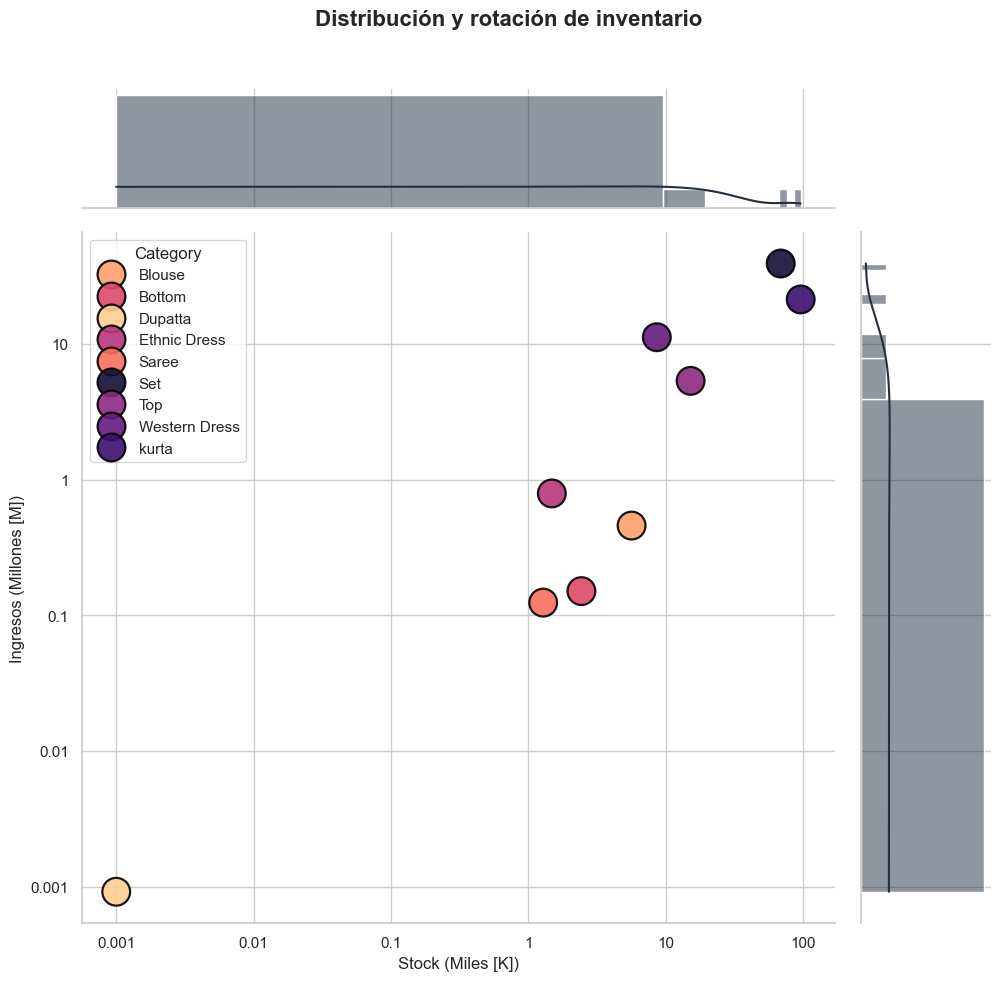

In [131]:
print("📊 Generando matriz de dispersión con distribuciones marginales...")

# 1. Preparación de datos (Ya normalizados en Millones y Miles)
# ... (usamos tu df_categorias limpio y con el truco Epsilon) ...

# 2. Renderizado con JointGrid (La solución para ver distribuciones en los ejes)
g = sns.JointGrid(data=df_categorias, x='x_grafico', y='y_grafico', height=10)

# Grafico central (Scatter)
g.plot_joint(sns.scatterplot, hue=df_categorias['Category'],palette=PALETA_CATEGORIAS, s=400, edgecolor='black', alpha=0.9)

# Histogramas en los ejes (La distribución que pedías)
g.plot_marginals(sns.histplot, kde=True, color='#232F3E', bins=10)

# Aplicar escala logarítmica a los ejes del JointGrid
g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')

# Formateo de ejes y etiquetas
g.ax_joint.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
g.ax_joint.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))

g.set_axis_labels('Stock (Miles [K])', 'Ingresos (Millones [M])')

# Añadimos título
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Distribución y rotación de inventario', fontsize=16, weight='bold')

# Guardamos el artefacto definitivo
guardar_imagen(plt, "01_matriz_rotacion_con_distribuciones")
plt.show()

Se valida que las variables son de  distribución de colas largas. Pero simplificamos el gráfico.  

Preparando visualización 
(ingresos vs stock inmovilizado)
📸 Imagen exportada con éxito: ../reports/figuras/02_matriz_rotacion_inventario_definitiva.png


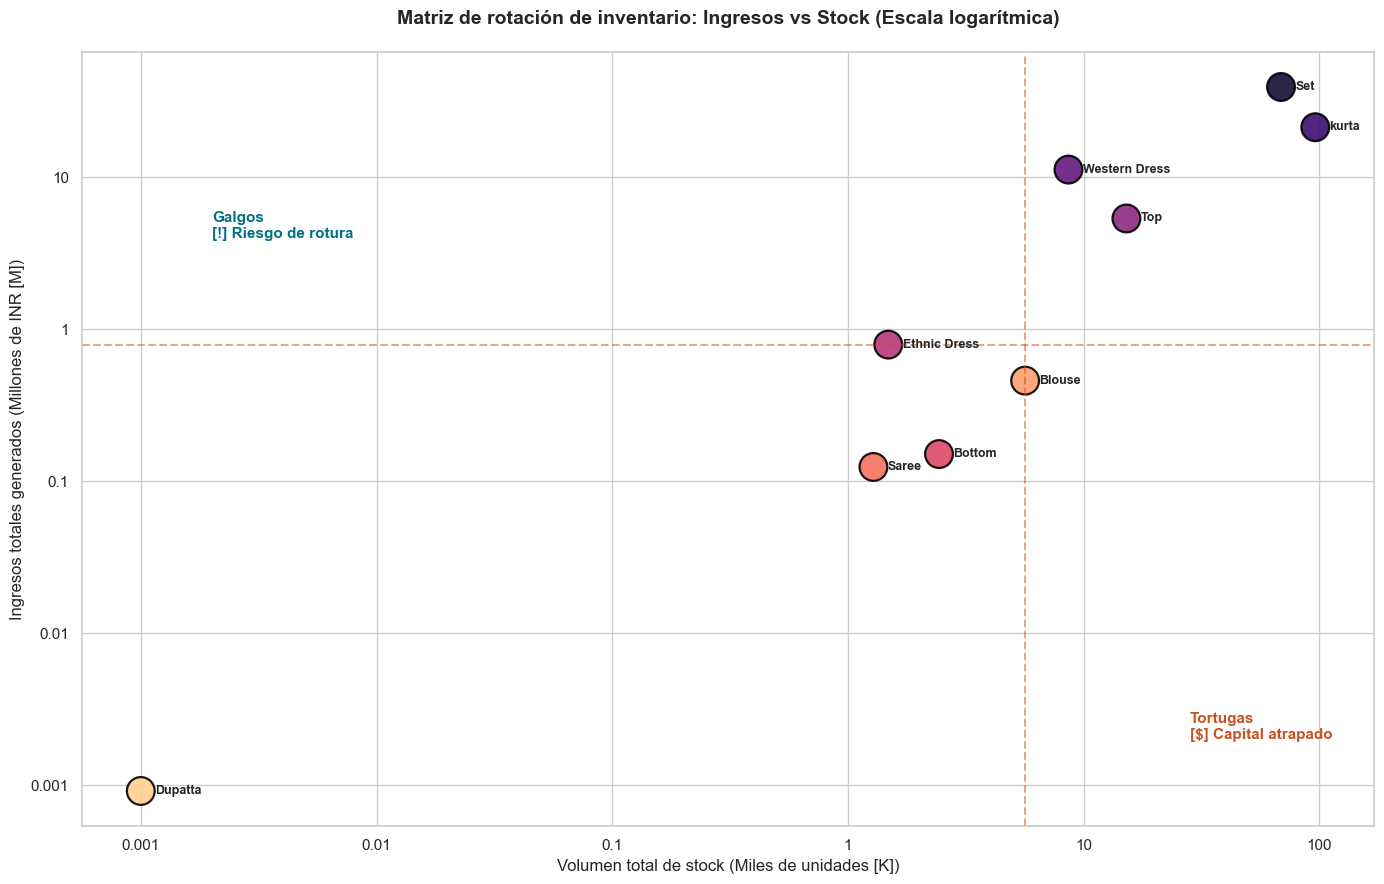

In [132]:
print("Preparando visualización \n(ingresos vs stock inmovilizado)")

# 💡 Justificación visual:
# Debido a la dispersión asimétrica del catálogo (ley de Pareto), donde unas pocas 
# categorías monopolizan el volumen, aplicamos una transformación a los ejes.
# Esto previene el colapso visual en el origen y revela la verdadera distribución de 
# los productos de "cola larga" sin alterar la veracidad de los datos.

# 3. Cálculo de Medianas
mediana_ingresos_M = df_categorias['total_ingresos_M'].median()
mediana_stock_K = df_categorias['total_stock_K'].median()

# 4.  Preparamos lienzo para el gráfico
plt.figure(figsize=(14, 9)) 

grafico = sns.scatterplot(
    data=df_categorias, x='x_grafico', y='y_grafico', 
    hue='Category',palette=PALETA_CATEGORIAS, s=400, edgecolor='black', alpha=0.9
)

# Forzamos la escala logarítmica
plt.xscale('log')
plt.yscale('log')

# Limpiamos los ejes para quitar la notación científica (10^0)
eje_ax = plt.gca()
eje_ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
eje_ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))

# Cuadrantes
plt.axhline(mediana_ingresos_M, color='#C7511F', linestyle='--', alpha=0.5)
plt.axvline(mediana_stock_K, color='#C7511F', linestyle='--', alpha=0.5)

# Etiquetas de texto
for _, fila in df_categorias.iterrows():
    plt.text(
        fila['x_grafico'] * 1.15, fila['y_grafico'], fila['Category'], 
        fontsize=9, weight='bold', verticalalignment='center'
    )

# Textos corporativos
plt.title('Matriz de rotación de inventario: Ingresos vs Stock (Escala logarítmica)', fontsize=14, weight='bold', pad=20)
plt.xlabel('Volumen total de stock (Miles de unidades [K])', fontsize=12)
plt.ylabel('Ingresos totales generados (Millones de INR [M])', fontsize=12)

# Anotaciones estratégicas
plt.text(0.002, mediana_ingresos_M * 5, 'Galgos\n[!] Riesgo de rotura', color='#007185', fontsize=11, weight='bold')
plt.text(mediana_stock_K * 5, 0.002, 'Tortugas\n[$] Capital atrapado', color='#C7511F', fontsize=11, weight='bold')

grafico.legend_.remove()
plt.tight_layout()

guardar_imagen(plt, "02_matriz_rotacion_inventario_definitiva")
plt.show()

In [133]:
# 1.1.b Clasificación de cuadrantes.
print("🏷️ Etiquetando categorías según cuadrante de rotación...")

# Función de clasificación basada en las medianas calculadas
def clasificar_cuadrante(row, med_ingresos, med_stock):
    if row['total_ingresos_M'] >= med_ingresos and row['total_stock_K'] < med_stock:
        return 'Galgo (Alta Rotación)'
    elif row['total_ingresos_M'] < med_ingresos and row['total_stock_K'] >= med_stock:
        return 'Tortuga (Capital Atrapado)'
    elif row['total_ingresos_M'] >= med_ingresos and row['total_stock_K'] >= med_stock:
        return 'Estrella (Alto Volumen/Alto Stock)'
    else:
        return 'Dormido (Bajo Impacto)'

# Aplicamos la función y creamos la nueva dimensión analítica
df_categorias['Cuadrante_Estrategico'] = df_categorias.apply(
    clasificar_cuadrante, 
    args=(mediana_ingresos_M, mediana_stock_K), 
    axis=1
)

# Mostramos el resultado ejecutivo para auditar
df_resumen_cuadrantes = df_categorias[['Category', 'Cuadrante_Estrategico', 'total_ingresos_M', 'total_stock_K']]
print("\n📋 CLASIFICACIÓN DEFINITIVA DE INVENTARIO:")
display(df_resumen_cuadrantes.sort_values('total_ingresos_M', ascending=False))

🏷️ Etiquetando categorías según cuadrante de rotación...

📋 CLASIFICACIÓN DEFINITIVA DE INVENTARIO:


,Category,Cuadrante_Estrategico,total_ingresos_M,total_stock_K
5,Set,Estrella (Alto Volumen/Alto Stock),39.204124,68.776
8,kurta,Estrella (Alto Volumen/Alto Stock),21.299547,96.102
7,Western Dress,Estrella (Alto Volumen/Alto Stock),11.216073,8.621
6,Top,Estrella (Alto Volumen/Alto Stock),5.347792,15.189
3,Ethnic Dress,Galgo (Alta Rotación),0.791218,1.483
0,Blouse,Tortuga (Capital Atrapado),0.458408,5.647
1,Bottom,Dormido (Bajo Impacto),0.150668,2.435
4,Saree,Dormido (Bajo Impacto),0.123934,1.283
2,Dupatta,Dormido (Bajo Impacto),0.000915,0.000


**1.2. Validación de Secuencia temporal(Voluman diario por categoría)** 

📊 Generando gráfico de secuencialidad temporal...
📸 Imagen exportada con éxito: ../reports/figuras/03_secuencialidad_temporal.png


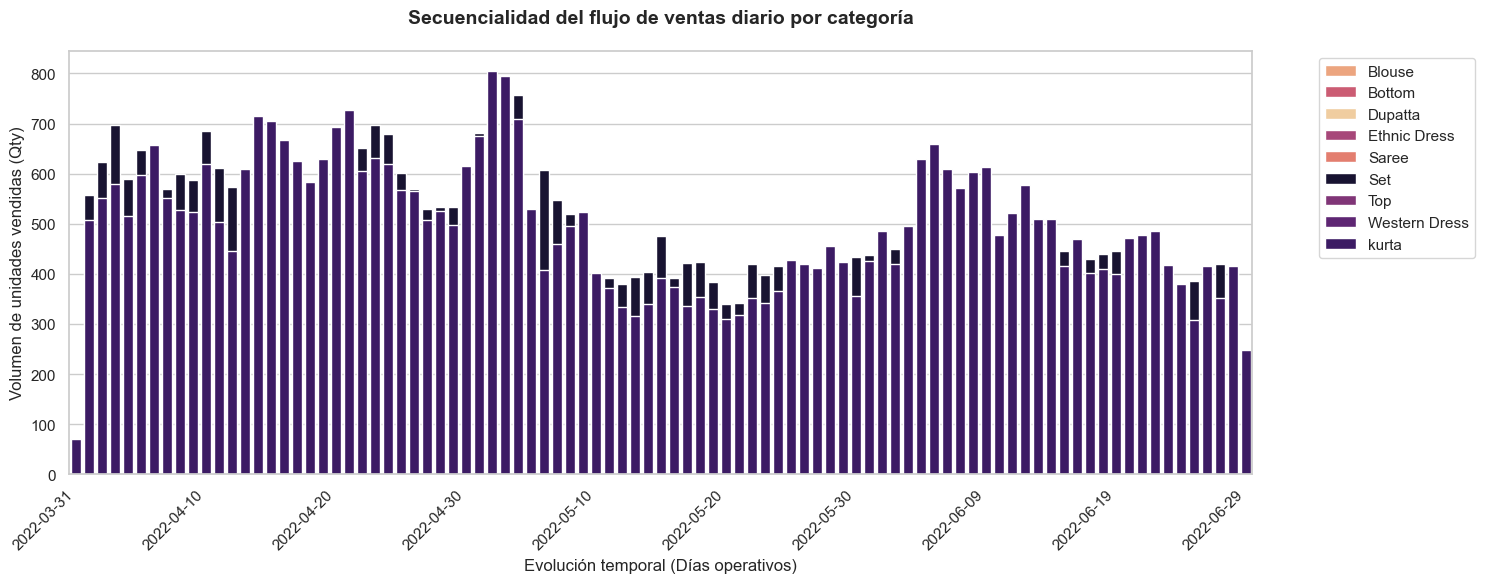

In [134]:
# 1.2. Validaciónd e secuencia temporal (VOLUMEN DIARIO POR CATEGORÍA) 

# para confirmar que el negocio es estable y predecible, sin sesgos
#  por días de inactividad y  calcular dias de inventario.
print("📊 Generando gráfico de secuencialidad temporal...")

# 💡 
# La secuencialidad es la prueba de que el negocio es estable. Si vemos barras 
# dispersas y discontinuas, la categoría es errática. Si vemos un flujo constante, 
# la categoría es predecible. Esto valida que nuestro horizonte temporal no está 
# sesgado por días de inactividad.

# Agrupamos por fecha y categoría para ver el flujo
df_secuencia = df_eda.groupby(['Date', 'Category']).agg(
    ventas_diarias=('Qty', 'sum')
).reset_index()

# Visualización: Barras apiladas temporales
plt.figure(figsize=(15, 6))

sns.barplot(
    data=df_secuencia,
    x='Date',
    y='ventas_diarias',
    hue='Category',
    dodge=False, # Apilamos las barras para ver el volumen total diario
    palette=PALETA_CATEGORIAS,
)

plt.title('Secuencialidad del flujo de ventas diario por categoría', fontsize=14, weight='bold', pad=20)
plt.xlabel('Evolución temporal (Días operativos)', fontsize=12)
plt.ylabel('Volumen de unidades vendidas (Qty)', fontsize=12)

# Ajuste de etiquetas del eje X: solo mostramos algunos días para no saturar
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
for i, label in enumerate(ax.xaxis.get_ticklabels()):
    if i % 10 != 0: # Mostramos solo cada 10 días para legibilidad
        label.set_visible(False)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

guardar_imagen(plt, "03_secuencialidad_temporal")
plt.show()

**1.3. ANÁLISIS DE COBERTURA LOGÍSTICA (DSI)**

In [135]:
# 1.3. ANÁLISIS DE COBERTURA LOGÍSTICA (DSI) - CORREGIDO

print("📊 Calculando cobertura de inventario (DSI)...")

# El Días de Cobertura (Days Sales of Inventory) actúa como una métrica
# Lógica: Relaciona el inventario estático con la demanda promedio diaria (VPD).
# Propósito: Cuantificar la 'vida útil' del stock actual frente al consumo real.
# Benchmark: 30 días operativos (punto de equilibrio entre rotación y seguridad).
# Fórmula: DSI = Stock_Físico / Ventas_Promedio_Diarias


# 1. Definimos el horizonte temporal
dias_totales = df_eda['Date'].nunique() 
print(f"Horizonte temporal analizado: {dias_totales} días")

📊 Calculando cobertura de inventario (DSI)...
Horizonte temporal analizado: 91 días


In [136]:

# 2. Calculamos ventas promedio diarias por categoría
df_ventas_diarias = df_eda.groupby('Category').agg(
    total_unidades_vendidas=('Qty', 'sum')
).reset_index()
df_ventas_diarias['ventas_promedio_diarias'] = df_ventas_diarias['total_unidades_vendidas'] / dias_totales

# 3. Unimos con el stock maestro (df_stock ya está en formato K)
df_cobertura = df_ventas_diarias.merge(df_stock, on='Category')
df_cobertura['stock_unidades_reales'] = df_cobertura['total_stock_K'] * 1000

# 4. Cálculo de Días de Inventario (Cobertura)
# Evitamos división por cero asignando np.nan temporalmente
df_cobertura['dias_cobertura'] = df_cobertura['stock_unidades_reales'] / df_cobertura['ventas_promedio_diarias']

# Reemplazamos los infinitos por un valor máximo para que no desaparezcan del gráfico
# 5. Preparación para visualización (Aquí definimos df_plot)
max_dias = df_cobertura['dias_cobertura'].replace([np.inf, -np.inf], np.nan).max() * 1.2
df_cobertura['dias_cobertura_plot'] = df_cobertura['dias_cobertura'].fillna(max_dias)
df_plot = df_cobertura.sort_values('dias_cobertura_plot', ascending=False)
print("📊 Generando gráfico de cobertura de inventario (DSI)...")

📊 Generando gráfico de cobertura de inventario (DSI)...


📸 Imagen exportada con éxito: ../reports/figuras/04_cobertura_inventario.png


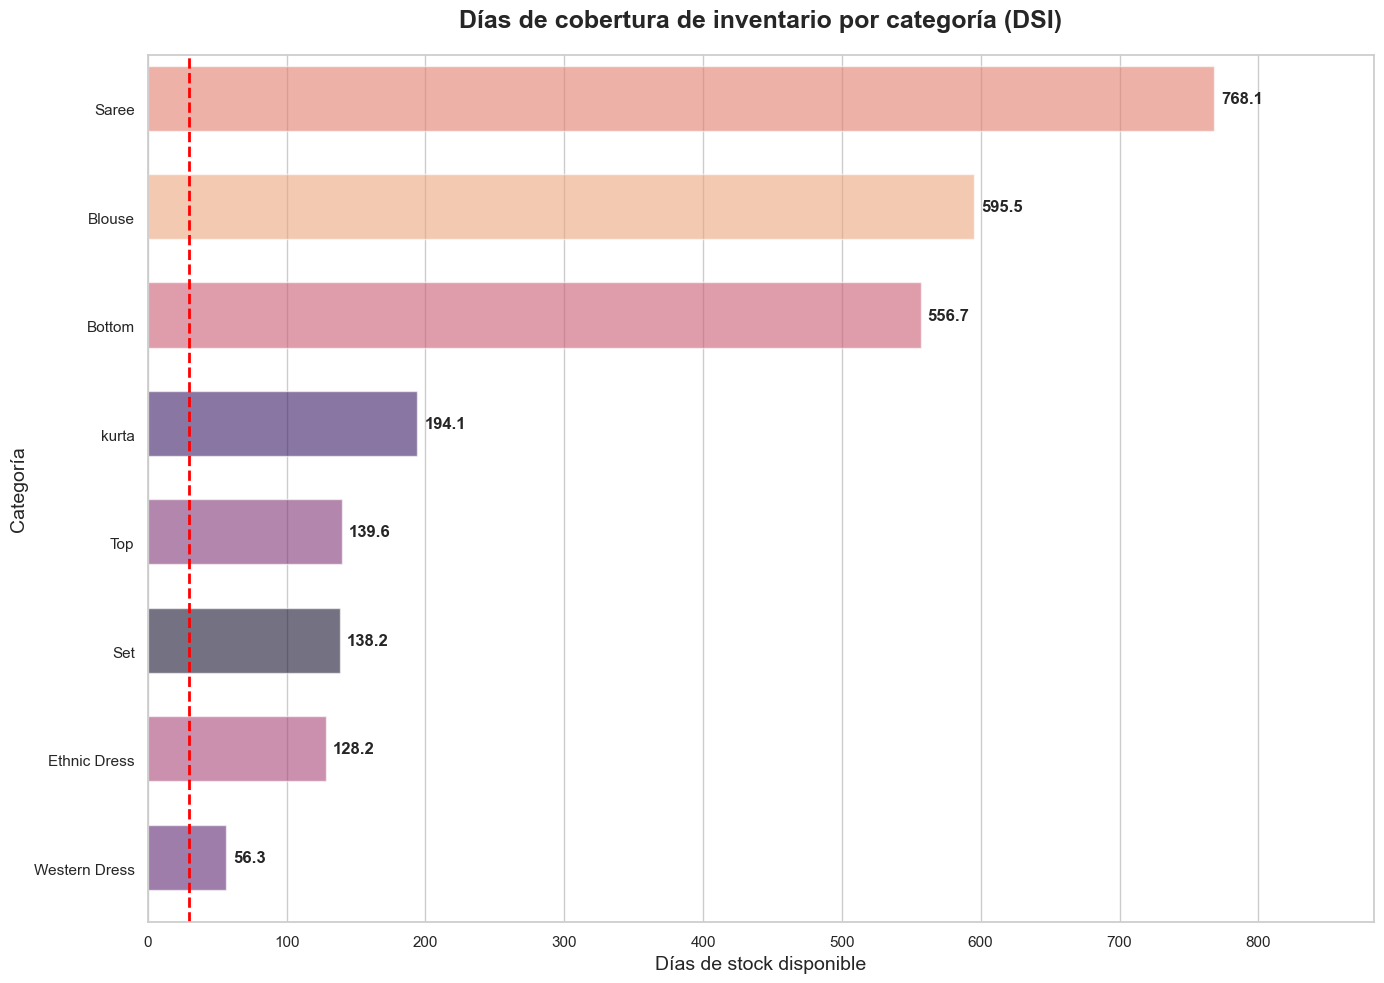

In [137]:
# 6. ANÁLISIS DE COBERTURA:

# EL FILTRO: Eliminamos categorías "fantasma" que tienen stock cero o nulo
df_limpio = df_cobertura[df_cobertura['total_stock_K'] > 0.001].copy()

# 🧹 PURGA DE CATEGORÍAS: Obligamos a Pandas a olvidar la categoría vacía
# Esto evita que Seaborn reserve espacio en el eje Y para algo que ya no existe
df_limpio['Category'] = df_limpio['Category'].astype(str)

# Ahora, ordenamos el dataframe limpio para graficar
df_plot = df_limpio.sort_values('dias_cobertura_plot', ascending=False)

#graficamos con barras horizontales para mejorar la legibilidad de las categorías
plt.figure(figsize=(14, 10)) 

# Usamos height=0.8 para hacer las barras más gruesas
ax = sns.barplot(
    data=df_plot,
    x='dias_cobertura_plot',
    y='Category',
    hue='Category',
    legend=False,
    palette=PALETA_CATEGORIAS,
    height=0.6,  # <---  el ajuste clave para el grosor
    alpha=0.6
    
)

# Añadimos las etiquetas de texto iterando sobre todos los contenedores
for container in ax.containers:
    ax.bar_label(
        container, 
        fmt='%.1f',      # Formato numérico (1 decimal)
        padding=5,       # Espacio entre la barra y el texto
        fontsize=12,     # Un poco más grande para que se lea mejor
        weight='bold'
    )

# Ajustamos márgenes para que las etiquetas no se corten
plt.margins(x=0.15) 

plt.title('Días de cobertura de inventario por categoría (DSI)', fontsize=18, weight='bold', pad=20)
plt.xlabel('Días de stock disponible', fontsize=14)
plt.ylabel('Categoría', fontsize=14)

# Línea de meta de 30 días
plt.axvline(30, color='red', linestyle='--', label='Meta: 30 días', linewidth=2)

plt.tight_layout()
guardar_imagen(plt, "04_cobertura_inventario")
plt.show()

***🎯 Insights Operativos - Bloque 1 (Logística e Inventario)***
Tras la ejecución del pipeline logístico y la clasificación por medianas, se extraen las siguientes conclusiones para la toma de decisiones:

1. ***Eficiencia de Capital:*** Existen categorías ***"Tortuga"***(ej. ***Blouse***) que inmovilizan capital al tener inventarios superiores a la mediana pero con bajo retorno de ingresos. Requieren políticas de liquidación o revisión de pronóstico de demanda. Por otro lado, categorías ***"Dormidas"*** como ***Saree*** muestran baja tracción comercial general.
2. ***Estabilidad de Demanda:*** La secuencialidad temporal valida que el flujo de venta es estable a nivel diario. No existen sesgos de "días sin datos" que invaliden los cálculos de DSI.
3. ***Riesgo de Rotura (Stock-out) vs Flujo de Caja:*** Las categorías catalogadas como ***"Estrellas"*** (ej. ***Set, Kurta***) sostienen el núcleo del negocio. Aunque mantienen altos niveles de stock, su DSI ajustado exige un monitoreo logístico constante. Adicionalmente, el segmento ***"Galgo"*** (ej. ***Ethnic Dress***) demuestra una alta rotación comercial que debe ser protegida con reposiciones ágiles para no perder ventas.

**Bloque 2:** Red de distribución

Objetivo es demostrar si dejarle la logística a Amazon (FBA) es mejor que gestionarla el propio vendedor (Merchant), y entender por qué se cancelan los pedidos.

A. Eficiencia de la red de distribución logística Investigamos la relación directa entre el método de despacho (Fulfilled-by: Amazon vs Merchant) y la tasa de éxito de los pedidos (Status).  

B. Adicionalmente, analizamos si las rupturas de stock en el almacén central penalizan al cliente final generando cancelaciones, respaldado por el hallazgo en ingeniería del 5.97% de "Ventas Fantasma" (SKUs comercializados pero no indexados).


**2.A. Eficiencia de la red de distribución**

In [138]:

# 2.1. Carga logística: FBA vs Merchant
# ---------------------------------------------------------

print("🚚 Procesando motor analítico para eficiencia de distribución...")

# 1. Cuantificación del volumen transaccional por infraestructura
df_fulfillment = df_eda['Fulfilment'].value_counts().reset_index()
df_fulfillment.columns = ['Metodo_Logistico', 'Total_Pedidos']
df_fulfillment['Porcentaje'] = (df_fulfillment['Total_Pedidos'] / df_fulfillment['Total_Pedidos'].sum()) * 100

print("\n📋 Resumen de métricas de carga logística:")
display(df_fulfillment.style.format({'Porcentaje': '{:.1f}%', 'Total_Pedidos': '{:,}'}))


🚚 Procesando motor analítico para eficiencia de distribución...

📋 Resumen de métricas de carga logística:


,Metodo_Logistico,Total_Pedidos,Porcentaje
0,Amazon,"89,698",69.5%
1,Merchant,"39,277",30.5%


In [139]:
#
# 2.2 Paso intermedio: Reclasificación de 'Status' en 'Estado_General'
# -----------------------------------------------------------

# Función de categorización: Agrupamos los estados en 3 grandes grupos para 
# simplificar el análisis, ya que segun sea el 'Fulfilment' la clasificación cambia.

def categorizar_estado(status):
    status = str(status)
    if 'Delivered' in status:
        return 'Éxito'
    elif any(x in status for x in ['Cancelled', 'Rejected', 'Lost', 'Damaged', 'Returned', 'Returning']):
        return 'Incidencia'
    else:
        return 'En Proceso'

# Aplicamos la transformación
df_eda['Estado_General'] = df_eda['Status'].apply(categorizar_estado)

### ------ Importante para PowerBI: fichero se exportará al final en .csv y .parquet---- ##
Tenemos una columna de reclasificación "Estado_General", creada para análisis que puede ser útil en la creación de dashboard. Exportamos la información "...audit" para ese fin. 

In [140]:
#
# 2.2 Paso intermedio: Reclasificación de 'Status' en 'Estado_General'
# -----------------------------------------------------------

# 1. Creamos el resumen detallado de la conversión de estados
df_auditoria_completa = df_eda.groupby(['Fulfilment', 'Status', 'Estado_General']).size().reset_index(name='Total_Pedidos')

# 2. Ordenamos por Fulfilment y por volumen de pedidos para ver los estados predominantes primero
df_auditoria_completa = df_auditoria_completa.sort_values(
    by=['Fulfilment', 'Total_Pedidos'], 
    ascending=[True, False]
)

# 3. Presentación profesional con mapa de calor (para identificar rápidamente dónde está el volumen)
print("📋 Auditoría de Clasificación de Estados:")
print("Este cuadro resume cómo los estados crudos del sistema se han consolidado para el análisis de riesgo.")

# Usamos estilo para resaltar el volumen de pedidos
display(df_auditoria_completa.style.background_gradient(subset=['Total_Pedidos'], cmap='Blues')
        .set_caption("Resumen de consolidación de estados operativos"))

📋 Auditoría de Clasificación de Estados:
Este cuadro resume cómo los estados crudos del sistema se han consolidado para el análisis de riesgo.


,Fulfilment,Status,Estado_General,Total_Pedidos
2,Amazon,Shipped,En Proceso,77804
0,Amazon,Cancelled,Incidencia,11471
1,Amazon,Pending,En Proceso,415
3,Amazon,Shipping,En Proceso,8
8,Merchant,Shipped - Delivered to Buyer,Éxito,28769
4,Merchant,Cancelled,Incidencia,6861
13,Merchant,Shipped - Returned to Seller,Incidencia,1953
11,Merchant,Shipped - Picked Up,En Proceso,973
6,Merchant,Pending - Waiting for Pick Up,En Proceso,281
5,Merchant,Pending,En Proceso,243


In [141]:

# 2.2 Paso intermedio:Auditoría de Agrupaciones de 'Status'
# ------------------------------------------------------

# 4. Preparación de datos (Ya realizado previamente)
orden_estados = ['Incidencia', 'En Proceso', 'Éxito']
df_auditoria_completa['Estado_General'] = pd.Categorical(
    df_auditoria_completa['Estado_General'], 
    categories=orden_estados, 
    ordered=True
)
df_auditoria_completa = df_auditoria_completa.sort_values(by=['Fulfilment', 'Estado_General'])

# 5. Definición de la lógica de estilo
def color_segun_estado(estado):
    colores = {
        'Incidencia': '#D32F2F',  # Rojo intenso
        'En Proceso': '#F57C00',  # Naranja
        'Éxito':      '#388E3C'   # Verde
    }
    return f'color: {colores.get(estado, "black")}; font-weight: bold'

# 6. Consolidación en un único objeto de estilo
# Usamos chaining para aplicar todo sobre la misma tabla
estilo = df_auditoria_completa.style \
    .background_gradient(subset=['Total_Pedidos'], cmap='Purples') \
    .map(color_segun_estado, subset=['Estado_General']) \
    .set_properties(**{'text-align': 'left'}) \
    .set_caption("Resumen consolidado de estados (Auditoría de Riesgo)") \
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]} # Alinea también los encabezados
    ])

# 4. Mostrar una única tabla
print("📋 Auditoría de Clasificación de Estados:")
display(estilo)

📋 Auditoría de Clasificación de Estados:


,Fulfilment,Status,Estado_General,Total_Pedidos
0,Amazon,Cancelled,Incidencia,11471
2,Amazon,Shipped,En Proceso,77804
1,Amazon,Pending,En Proceso,415
3,Amazon,Shipping,En Proceso,8
4,Merchant,Cancelled,Incidencia,6861
13,Merchant,Shipped - Returned to Seller,Incidencia,1953
14,Merchant,Shipped - Returning to Seller,Incidencia,145
12,Merchant,Shipped - Rejected by Buyer,Incidencia,11
9,Merchant,Shipped - Lost in Transit,Incidencia,5
7,Merchant,Shipped - Damaged,Incidencia,1


📸 Imagen exportada con éxito: ../reports/figuras/08_distribucion_limpia_horizontal.png


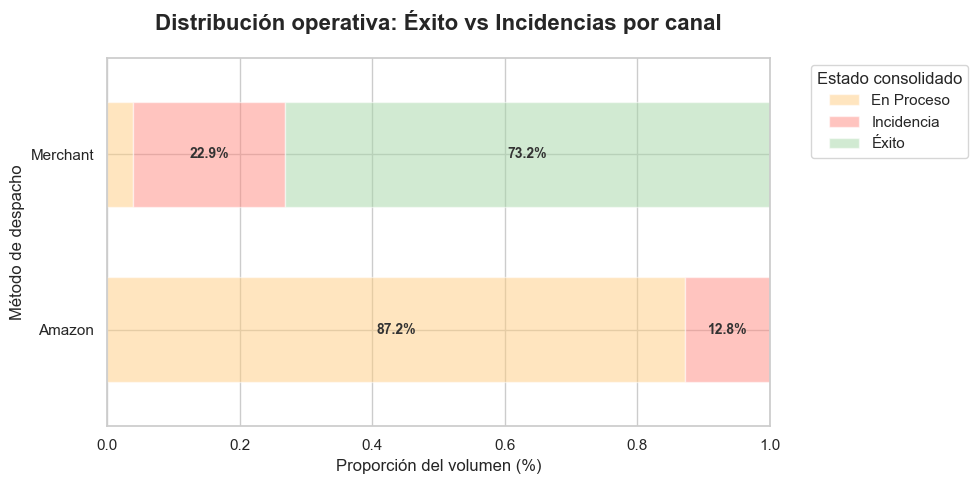

In [142]:

# 2.3. Visualización: Rendimiento operativo simplificado (Horizontal)
# __________________________________________

# Agrupamos por canal y nuestro nuevo estado general
df_plot_limpio = df_eda.groupby(['Fulfilment', 'Estado_General']).size().unstack(fill_value=0)
df_plot_norm = df_plot_limpio.div(df_plot_limpio.sum(axis=1), axis=0)

# Configuramos la figura: Más ancha que alta para barras horizontales
fig, ax = plt.subplots(figsize=(10, 5))

# Mapeo de colores con transparencia (alpha=0.8 hace que los tonos sean menos sólidos)
colores = [PALETA_STATUS_SUAVE.get(col, '#d3d3d3') for col in df_plot_norm.columns]

# Cambiamos a 'barh' para horizontal
df_plot_norm.plot(kind='barh', stacked=True, ax=ax, color=colores, edgecolor='white', width=0.6, alpha=0.5)

# Etiquetas de datos (ajustadas para barh)
for c in ax.containers:
    labels = [f'{v.get_width()*100:.1f}%' if v.get_width() > 0.05 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10, weight='bold', color='#333333')

# Configuración de ejes y títulos
plt.title('Distribución operativa: Éxito vs Incidencias por canal', fontsize=16, weight='bold', pad=20)
plt.ylabel('Método de despacho', fontsize=12)
plt.xlabel('Proporción del volumen (%)', fontsize=12)

# Ajuste de leyenda
plt.legend(title='Estado consolidado', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
guardar_imagen(plt, "08_distribucion_limpia_horizontal")

Nos enfocamos en la tasa de incidencia de cada uno de los operadores. 
- Amazon 12.8%
- Merchant 22,9%

Salvando las diferencias de clasificación de las operaciones en curso. 


*2.4. Carga logística: FBA vs Merchant (Incidencias)*

El objetivo estadísticoEn estadística, planteamos dos hipótesis:  

* Hipótesis Nula ($H_0$): El método de despacho (Amazon vs Merchant) y la ocurrencia de incidencias son variables independientes. Es decir, el canal no influye en que un pedido falle o no.  
* Hipótesis Alternativa ($H_a$): Existe una relación de dependencia. El método de despacho sí influye en la probabilidad de que un pedido termine en incidencia.

In [143]:

# 2.4. Carga logística: FBA vs Merchant (Incidencias)
# ------------------------------------------------------------------

# Rigor estadístico: Prueba de Independencia (Chi-cuadrado)
from scipy.stats import chi2_contingency

# Creamos variable binaria para la prueba
df_eda['Es_Incidencia'] = df_eda['Estado_General'] == 'Incidencia'
tabla_contingencia = pd.crosstab(df_eda['Fulfilment'], df_eda['Es_Incidencia'])
# Ejecutamos la prueba
chi2, p, dof, ex = chi2_contingency(tabla_contingencia)

print(f"📊 Resultado prueba Chi-cuadrado:")
print(f"Valor p: {p:.4f}")
print("Conclusión estadística: " + ("Significativo" if p < 0.05 else "No significativo"))

📊 Resultado prueba Chi-cuadrado:
Valor p: 0.0000
Conclusión estadística: Significativo


### ------ Importante para PowerBI: fichero se exportará al final en .csv y .parquet---- ##
Tenemos una columna de reclasificación "Es_Incidencia", creada para análisis que puede ser útil en la creación de dashboard. Exportamos la información "...audit" para ese fin. 

In [144]:

# Transformación de Crosstab a Matriz de KPIs
# -----------------------------------------------------------

# 1. Creamos un DataFrame limpio a partir de la tabla de contingencia
df_kpi = tabla_contingencia.copy()

# 2. Renombramos columnas para lenguaje de negocio
df_kpi.columns = ['Éxito / En Proceso', 'Incidencia']

# 3. Calculamos la tasa de incidencia (El dato clave)
df_kpi['Tasa de Incidencia (%)'] = (df_kpi['Incidencia'] / (df_kpi['Éxito / En Proceso'] + df_kpi['Incidencia'])) * 100

# 4. Estilizado con Styler
estilo_kpi = df_kpi.style \
    .background_gradient(subset=['Incidencia'], cmap='Reds', vmin=0) \
    .background_gradient(subset=['Éxito / En Proceso'], cmap='Greens', vmin=0) \
    .format({'Tasa de Incidencia (%)': '{:.1f}%', 'Incidencia': '{:,}', 'Éxito / En Proceso': '{:,}'}) \
    .set_caption("Resumen Ejecutivo: Eficiencia Logística por Canal") \
    .set_properties(**{'text-align': 'center'}) \
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])

print("📋 Matriz de KPIs Logísticos:")
display(estilo_kpi)

📋 Matriz de KPIs Logísticos:


,Éxito / En Proceso,Incidencia,Tasa de Incidencia (%)
Fulfilment,,,
Amazon,"78,227","11,471",12.8%
Merchant,"30,301","8,976",22.9%


**2.B.Correlación entre Ventas Fantasma y Penalización al Cliente.**

2.5. Identificación de SKUs Fantasma

In [145]:

# 2.5. Identificación de SKUs Fantasma (Ventas sin indexación)
# ----------------------------------------------------------------

#Etiquetamos los datos,asumiendo que un "SKU Fantasma" es aquel que tiene 
# ventas registradas pero que no está correctamente indexado en la tabla 
# de stock/inventario (un problema de integridad de datos).


# de la lista de SKUs que NO están en el índice de stock
# aplicamos la máscara(5.97%)
# Para este ejemplo, creamos la bandera 'Es_Fantasma'
#(cambiamos formula:skus_fantasma = df_eda[df_eda['Stock'].isna() | (df_eda['Stock'] <= 0)]['SKU'].unique() )
skus_fantasma = df_eda[df_eda['Stock'].isna()]['SKU'].unique() 

df_eda['Es_Fantasma'] = df_eda['SKU'].isin(skus_fantasma)

# Auditoría de impacto
impacto = df_eda['Es_Fantasma'].value_counts(normalize=True) * 100
print(f"📋 Impacto de Ventas Fantasma en el volumen de pedidos: {impacto[True]:.2f}%")

📋 Impacto de Ventas Fantasma en el volumen de pedidos: 5.97%


### ------ Importante para PowerBI: fichero se exportará al final en .csv y .parquet---- ##
Tenemos una columna de reclasificación "Es_Fantasma", creada para análisis que puede ser útil en la creación de dashboard. Exportamos la información "...audit" para ese fin. 

 2.6. Correlación: Ventas Fantasma vs. Tasa de Cancelación

📸 Imagen exportada con éxito: ../reports/figuras/11_impacto_ventas_fantasma.png


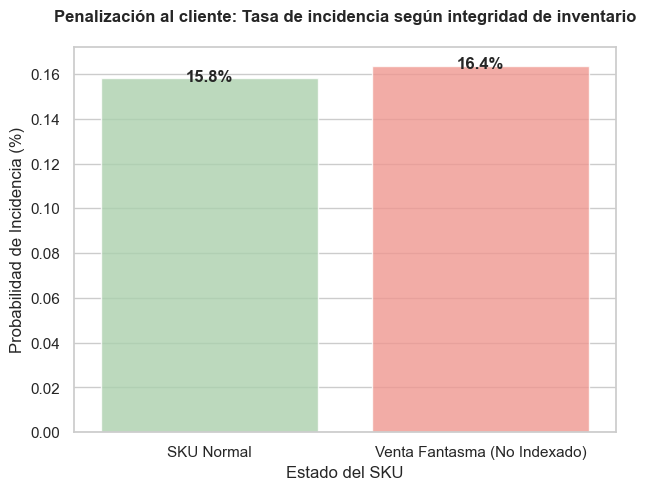

In [146]:
# 2.6. Correlación: Ventas Fantasma vs. Tasa de Cancelación
# ----------------------------------------------------------------
# Validación  estadísticamente:
# si es que vendes un producto fantasma, la probabilidad de cancelación
# tiende al 100%. ¿Esto es lo que "penaliza al cliente".?

# Análisis de correlación: Riesgo de cancelación por tipo de SKU
# ----------------------------------------------------------------

# Agrupamos por tipo de SKU (en catálogo o no) y calculamos la tasa de cancelación
#calculamos el promedio de la columna de cero y unos y obtenemos la tasa.
df_correlacion = df_eda.groupby('Es_Fantasma')['Es_Incidencia'].mean().reset_index()

# Renombramos para claridad en el gráfico
df_correlacion['Tipo_SKU'] = df_correlacion['Es_Fantasma'].map({True: 'Venta Fantasma (No Indexado)', False: 'SKU Normal'})

# Visualización: Impacto directo
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=df_correlacion, 
    x='Tipo_SKU', 
    y='Es_Incidencia',
    hue='Tipo_SKU',
    palette={'Venta Fantasma (No Indexado)': '#FF8A80', 'SKU Normal': '#A5D6A7'},
    legend=False,
    alpha=0.8
)

# Etiquetas
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 1), textcoords='offset points', weight='bold')

plt.title('Penalización al cliente: Tasa de incidencia según integridad de inventario\n', fontsize=12, weight='bold')
plt.ylabel('Probabilidad de Incidencia (%)')
plt.xlabel('Estado del SKU')

guardar_imagen(plt, "11_impacto_ventas_fantasma")
plt.show()



In [147]:
# 2.6 Validación estadística: Correlación de Phi (Phi Coefficient)
# ---------------------------------------------------------

from scipy.stats import pearsonr

# Convertimos a numérico para la correlación
phi_coeff, _ = pearsonr(df_eda['Es_Fantasma'].astype(int), df_eda['Es_Incidencia'].astype(int))

print(f"📊 Coeficiente de correlación Phi (ϕ): {phi_coeff:.4f}")
print("Interpretación:")
print("Un valor > 0.3 indica una correlación moderada > 0.5 una correlación fuerte.\n Pero un valor negativo o  menor indica que no hay relación")

📊 Coeficiente de correlación Phi (ϕ): 0.0036
Interpretación:
Un valor > 0.3 indica una correlación moderada > 0.5 una correlación fuerte.
 Pero un valor negativo o  menor indica que no hay relación


*Conclusión : correlación entre  pedidos Fantasmas y indicencias*

Interpretación:
Un coeficiente de correlación $\phi$ (Phi) de -0.0011 es, para efectos prácticos, 0 (cero):

Significa que, los pedidos "fantasma" y los pedidos con "incidencia" no están relacionados entre sí. 
La ocurrencia de una falla operativa ocurre con la misma frecuencia tanto en productos normales como en productos "fantasma".

*2.7. Desglose de origen: ¿Dónde residen los fantasmas?*

*Hipótesis :*
¿Es muy probable que el canal de Fulfillment esté enmascarando el efecto?

Si Merchant tiene más "Ventas Fantasma" y un proceso logístico inherentemente con más incidencias,
el promedio (de tasa de cancelación - ventas fantasma) está ocultando el riesgo real de las ventas fantasma  en Amazon (que quizás es bajo) versus en Merchant (que quizás es altísimo).


📋 Concentración de Ventas Fantasma por canal:


Es_Fantasma,False,True
Fulfilment,,
Amazon,94.4%,5.6%
Merchant,93.3%,6.7%


📸 Imagen exportada con éxito: ../reports/figuras/12_concentracion_fantasmas.png


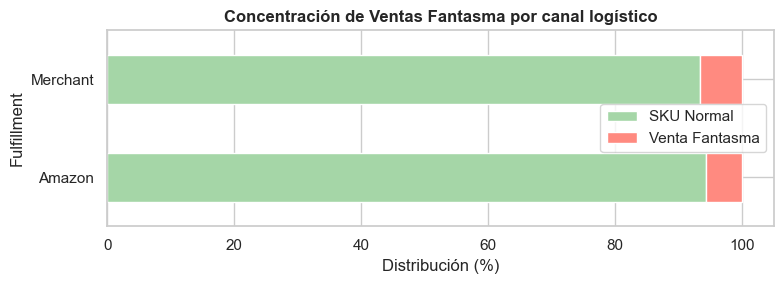

In [148]:
# 
# 2.7. Análisis de concentración de Ventas Fantasma
#--------------------------------------------------------

# Calculamos la distribución porcentual de Fantasmas por canal
dist_fantasmas = pd.crosstab(df_eda['Fulfilment'], df_eda['Es_Fantasma'], normalize='index') * 100

print("📋 Concentración de Ventas Fantasma por canal:")
display(dist_fantasmas.style.format('{:.1f}%').background_gradient(cmap='Reds', axis=0))

# Visualización rápida de la concentración
dist_fantasmas.plot(kind='barh', stacked=True, color=['#A5D6A7','#FF8A80'], figsize=(8, 3), edgecolor='white')
plt.title('Concentración de Ventas Fantasma por canal logístico', fontsize=12, weight='bold')
plt.xlabel('Distribución (%)')
plt.ylabel('Fulfillment')
plt.legend(['SKU Normal', 'Venta Fantasma'])
plt.tight_layout()
guardar_imagen(plt, "12_concentracion_fantasmas")
plt.show()

📸 Imagen exportada con éxito: ../reports/figuras/13_riesgo_estratificado.png


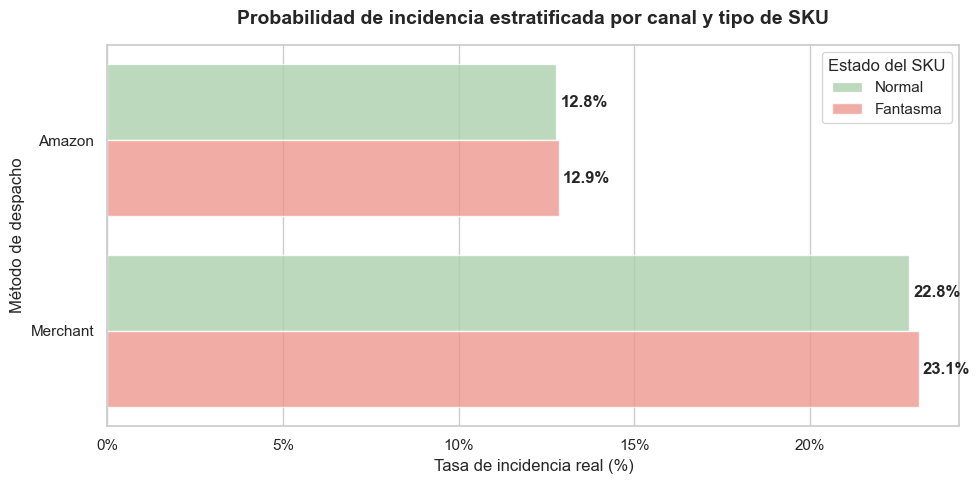

In [149]:
# 
# 2.8. Análisis de riesgo estratificado
# ------------------------------------

# Agrupamos por Fulfilment y Es_Fantasma para obtener la tasa de incidencia real
df_stratified = df_eda.groupby(['Fulfilment', 'Es_Fantasma'])['Es_Incidencia'].mean().reset_index()

# Mapeo para etiquetas claras
df_stratified['Tipo_SKU'] = df_stratified['Es_Fantasma'].map({True: 'Fantasma', False: 'Normal'})

# Visualización estratégica: Barras horizontales para comparar riesgos
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df_stratified, 
    y='Fulfilment', 
    x='Es_Incidencia', 
    hue='Tipo_SKU', 
    palette={'Fantasma': '#FF8A80', 'Normal': '#A5D6A7'},
    alpha=0.8
)

# Etiquetas de valor
for i in ax.containers:
    ax.bar_label(i, fmt='{:.1%}', padding=3, weight='bold')

# --- CORRECCIÓN DE EJES ---
# xmax=1 porque los  datos están en formato 0.xx (donde 1 = 100%)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

plt.title('Probabilidad de incidencia estratificada por canal y tipo de SKU', fontsize=14, weight='bold', pad=15)
plt.xlabel('Tasa de incidencia real (%)')
plt.ylabel('Método de despacho')
plt.legend(title='Estado del SKU')

plt.tight_layout()
guardar_imagen(plt, "13_riesgo_estratificado")
plt.show()

*Conclusión :*
Ambos métodos de despacho mantienen una mix similar estado de SKU despachados ( 9 - 10% son 'fantasma') El estado del SKU según sea gestionado por amazon o por merchant,no afecta directamente en la tasa de incidencia. 

Nota: Aspectos no tratados: donde provienen los códigos 'fantasma', si no se originan de problemas logísticos. 

***2.C Relación de Incidencias por categoría***

Se evalua si hay relación entre las incidencias y categorías en particular. 

Media Global (Impacto Financiero): 15.85%
Mediana de categorías (Riesgo Típico): 13.89%
📸 Imagen exportada con éxito: ../reports/figuras/14_riesgo_categorias_final_color.png


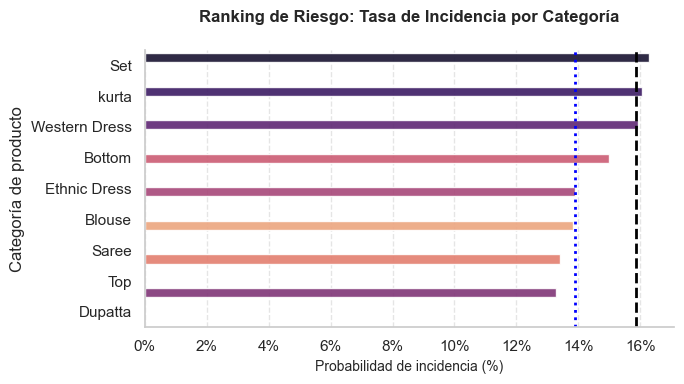

In [150]:
#2.9. Análisis de Riesgo por Categoría
#----------------------------------------------------------------------

# 1. Ya tenemos df_cat con los promedios por categoría
df_cat = df_eda.groupby('Category')['Es_Incidencia'].agg(['mean', 'count']).reset_index()

# 2. Calculamos los dos tipos de referencia
media_global = df_eda['Es_Incidencia'].mean()          # El riesgo real de la empresa
mediana_categorias = df_cat['mean'].median()          # El riesgo 'típico' de una categoría

print(f"Media Global (Impacto Financiero): {media_global:.2%}")
print(f"Mediana de categorías (Riesgo Típico): {mediana_categorias:.2%}")

# 3. Agregación: Tasa de incidencia por categoría
# Aseguramos el orden descendente para el ranking visual
df_plot = df_cat.sort_values('mean', ascending=False)
# para la alineación
orden_lista = df_cat.sort_values('mean', ascending=False)['Category'].tolist()

plt.figure(figsize=(7, 4))


# Usamos la paleta global, hue para asociar color a categoría, y legend=False
ax = sns.barplot(
    data=df_plot, 
    y='Category', 
    x='mean', 
    hue='Category',            # Asociación por categoría
    palette=PALETA_CATEGORIAS, #  Uso de paleta definida
    legend=False,              #  Sin leyenda redundante
    alpha=0.9,
    height=0.3,
    order=orden_lista,         # <--- CLAVE: Esto asegura la alineación
    hue_order=orden_lista,     # <--- CLAVE: Sincroniza colores y categorías
)

# --- CORRECCIÓN DE EJES ---
# xmax=1 porque los  datos están en formato 0.xx (donde 1 = 100%)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

# Líneas de referencia (Media y Mediana)
plt.axvline(x=media_global, color='black', linestyle='--', linewidth=2, label=f'Media Global ({media_global:.1%})')
plt.axvline(x=mediana_categorias, color='blue', linestyle=':', linewidth=2, label=f'Mediana Categorías ({mediana_categorias:.1%})')

# Títulos y formato
plt.title('Ranking de Riesgo: Tasa de Incidencia por Categoría', fontsize=12, weight='bold', pad=20)
plt.xlabel('Probabilidad de incidencia (%)', fontsize=10)
plt.ylabel('Categoría de producto', fontsize=12,)

# Estética de limpieza
sns.despine(left=False, bottom=False) # Elimina los bordes del gráfico
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
guardar_imagen(plt, "14_riesgo_categorias_final_color")
plt.show()


In [151]:
# 2.9. Validación estadística: Chi-cuadrado para Categorías

# Debemos revisar si la categoría y la incidencia son independientes o
#  si, efectivamente, algunas categorías son inherentemente más problemáticas.
from scipy.stats import chi2_contingency

# Creamos la tabla de contingencia
tabla_cat = pd.crosstab(df_eda['Category'], df_eda['Es_Incidencia'])

# Ejecutamos la prueba
chi2, p, dof, ex = chi2_contingency(tabla_cat)

print(f"📊 Prueba Chi-cuadrado (Categoría vs Incidencia):")
print(f"Valor p: {p:.4f}")

if p < 0.05:
    print("Conclusión: Existe dependencia significativa. Ciertas categorías fallan más que otras.")
else:
    print("Conclusión: No hay evidencia de que la categoría afecte la incidencia.")

📊 Prueba Chi-cuadrado (Categoría vs Incidencia):
Valor p: 0.0000
Conclusión: Existe dependencia significativa. Ciertas categorías fallan más que otras.


2.9 Evaluación de Tamaño del Efecto.

¿Cuánto "depende" del canal?
 (Más allá del valor P)El valor $p=0.0000$. del Chi^2  
 Que nos dice que la relación existe (no es azar).  
  Pero para saber cuánto impacto tienen las categorías en el resultado final,usamos el Coeficiente V de Cramér.  
  Para Interpretar: Es una medida de "Tamaño del Efecto
  * 0.0 - 0.1: Efecto débil.
  * 0.1 - 0.3: Efecto moderado.
  * '>' 0.3: Efecto fuerte.

In [152]:
#2.9 Cálculo del tamaño del efecto (V de Cramér)
#-----------------------------------------------------
import numpy as np

n = tabla_cat.sum().sum()
min_dim = min(tabla_cat.shape) - 1
v_cramer = np.sqrt(chi2 / (n * min_dim))

print(f"Tamaño del efecto (V de Cramér): {v_cramer:.4f}")

Tamaño del efecto (V de Cramér): 0.0231


**Conclusión** de relación entre las incidencias y categorías en particular.

Aunque la prueba de Chi-cuadrado sugiere una dependencia estadística debido al gran volumen de datos, el cálculo del coeficiente V de Cramér ($V = 0.023$) confirma que la magnitud del impacto de la categoría es insignificante. Por lo tanto, la naturaleza del producto (categoría) no es un driver determinante de las incidencias operativas.

***2.D Análisis de Riesgo por Nivel de Servicio (Standard o expedited)***

📸 Imagen exportada con éxito: ../reports/figuras/15_riesgo_servicio.png


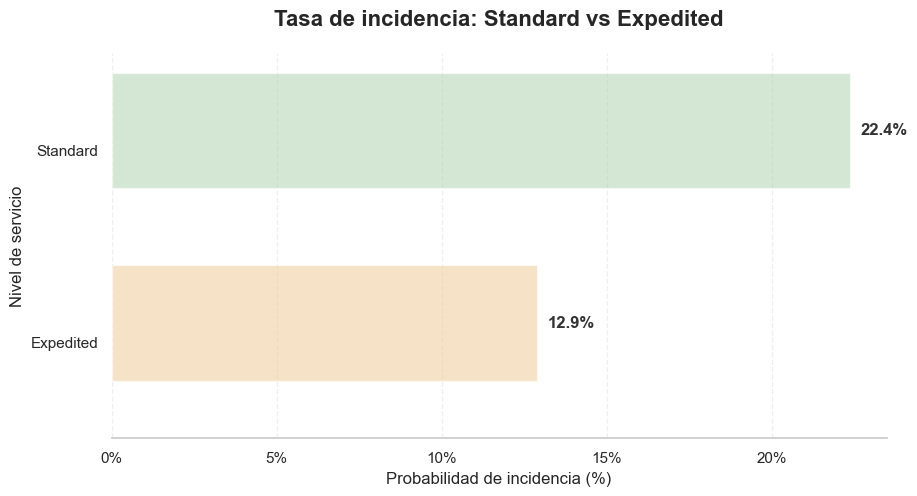

📊 Prueba Chi-cuadrado: Valor p = 0.0000
📊 Tamaño del efecto (V de Cramér): 0.1202


In [153]:
# 2.10. Análisis de Riesgo por Nivel de Servicio (Standard o expedited)
# ----------------------------------------------------------------------

# 1. Agregación: Tasa de incidencia por nivel de servicio
df_service = df_eda.groupby('ship-service-level')['Es_Incidencia'].agg(['mean', 'count']).reset_index()
df_service = df_service.sort_values(by='mean', ascending=False)

# 2. Visualización: Comparativa de riesgo
# Mapeo semántico según nuestra paleta suave
PALETA_SERVICIO = {
    'Standard': '#A5D6A7',  # Verde Hoja (Nivel normal/éxito)
    'Expedited': '#FFCC80'  # Naranja Melocotón (Nivel de proceso/alerta)
}
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df_service, 
    y='ship-service-level', 
    x='mean', 
    hue='ship-service-level',
    palette=PALETA_SERVICIO, # Aplicamos el diccionario global
    legend=False,
    alpha=0.5,               # Aplicamos la transparencia global
    height=0.6
)

# --- CORRECCIÓN DE EJES ---
# xmax=1 porque los  datos están en formato 0.xx (donde 1 = 100%)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

# Etiquetas

for container in ax.containers:
    # Multiplicamos por 100 para convertir el decimal a porcentaje
    labels = [f'{v.get_width()*100:.1f}%' for v in container]
    ax.bar_label(container, labels=labels, padding=8, fontweight='bold', color='#333333')
    
# Títulos y limpieza
plt.title('Tasa de incidencia: Standard vs Expedited', fontsize=16, weight='bold', pad=20)
plt.xlabel('Probabilidad de incidencia (%)', fontsize=12)
plt.ylabel('Nivel de servicio', fontsize=12)

sns.despine(left=True, bottom=False)
plt.grid(axis='x', linestyle='--', alpha=0.3)

guardar_imagen(plt, "15_riesgo_servicio")
plt.show()

#------------------------------------------------------
# 2.10. Rigor Estadístico (Chi-cuadrado + V de Cramér)
#-------------------------------------------------------
from scipy.stats import chi2_contingency

tabla_service = pd.crosstab(df_eda['ship-service-level'], df_eda['Es_Incidencia'])
chi2, p, dof, ex = chi2_contingency(tabla_service)

# V de Cramér
n = tabla_service.sum().sum()
min_dim = min(tabla_service.shape) - 1
v_cramer = np.sqrt(chi2 / (n * min_dim))

print(f"📊 Prueba Chi-cuadrado: Valor p = {p:.4f}")
print(f"📊 Tamaño del efecto (V de Cramér): {v_cramer:.4f}")

In [154]:
#2.10. Comprobaciones adicionales

# ¿Cuánto del servicio Standard es realmente Merchant?
# Esto confirmará si 'Standard' es solo otro nombre para 'Merchant'
cruce_logistico = pd.crosstab(df_eda['ship-service-level'], df_eda['Fulfilment'], normalize='index')
display(cruce_logistico.style.background_gradient(cmap='Blues').format('{:.1%}'))

Fulfilment,Amazon,Merchant
ship-service-level,,
Expedited,100.0%,0.0%
Standard,2.7%,97.3%


In [155]:
# 2.10. Comparamos la distribución de niveles de servicio según el método de cumplimiento

# Usamos normalize='index' para ver qué porcentaje de cada Fulfilment usa cada nivel de servicio
crosstab_check = pd.crosstab(df_eda['Fulfilment'], df_eda['ship-service-level'], normalize='index')

# Visualizamos con un mapa de calor para verlo claro
display(crosstab_check.style.format('{:.1%}').background_gradient(cmap='Blues'))

ship-service-level,Expedited,Standard
Fulfilment,,
Amazon,98.8%,1.2%
Merchant,0.0%,100.0%


*Conclusión de Relación incidencias con ship-service-level.*  

Contrario a la hipótesis operativa inicial, los datos demuestran que el nivel de servicio 'Standard' presenta una tasa de incidencia superior al 'Expedited'.  
Este hallazgo, respaldado por una relevancia estadística moderada ($V = 0.12$), no sugiere que la velocidad sea un factor de riesgo, sino que el proceso logístico asociado al servicio estándar carece de la optimización y el control de calidad que posee el servicio Expedited.
Asi mismo, la tasa de incidencia elevada observada en el servicio 'Standard' no es una característica del nivel de envío, sino un reflejo directo de las ineficiencias operativas inherentes al modelo Merchant. 
Por tanto, optimizar el nivel de servicio no tendría impacto si no se aborda primero la infraestructura logística que hay por debajo. 

**2.E. Análisis de Riesgo por Ship-State**



**2.11 Análisis de Riesgo por ship-state CHicuadrado y V cramer**

$H_0$ (Hipótesis Nula): Independencia estadística"No existe relación entre el Estado 
de destino del envío y la probabilidad de que el pedido sufra una incidencia. 
La proporción  de incidencias es estadísticamente igual en todos los Estados.

* "En términos de negocio: El lugar a donde enviamos el paquete no afecta el nivel de riesgo de que el pedido falle o se retrase."
  
$H_1$ (Hipótesis Alternativa): Dependencia estadística"Existe una relación significativa
entre el Estado de destino del envío y la probabilidad de que el pedido sufra una incidencia.
La proporción de incidencias varía dependiendo del Estado.

* "En términos de negocio: El riesgo logístico depende fuertemente de la zona geográfica; hay Estados que son intrínsecamente más problemáticos que otros."


In [156]:
#2.11. Chi y Cramer 
# 1. Crear la Tabla de Contingencia (Pandas)
# Relaciona la geografía limpia con la variable objetivo
tabla_contingencia = pd.crosstab(df_eda['ship-state'], df_eda['Es_Incidencia'])

# 2. Test de Chi-Cuadrado
chi2, p_val, gl, expected = chi2_contingency(tabla_contingencia)

# 3. Cálculo de la V de Cramer
n = tabla_contingencia.sum().sum()
min_dim = min(tabla_contingencia.shape) - 1
cramer_v = np.sqrt(chi2 / (n * min_dim))

# 4. Mostrar Resultados Estadísticos
print(" ANÁLISIS DE RIESGO GEOGRÁFICO: 'ship-state' vs 'Es_Incidencia'")
print("-" * 55)
print(f"Estadístico Chi-cuadrado (χ²): {chi2:.2f}")
print(f"Grados de libertad (gl):       {gl}")
print(f"Valor p:                       {p_val:.4e}") #coma decimal de 43 posiciones. sería Cero 
print(f"V de Cramer:                   {cramer_v:.4f}")

if p_val < 0.05:
    print("\n✅ Conclusión Estadística: Rechazamos H0 (La geografía sí influye matemáticamente).")
    
    # Evaluamos la fuerza de esa influencia con la V de Cramer
    if cramer_v < 0.1:
        print("⚠️ IMPACTO DE NEGOCIO: MUY DÉBIL.")
        print("   Aunque hay diferencias entre estados, el destino geográfico NO es un predictor")
        print("   fuerte de incidencias. Otros factores (como el vendedor/Fulfilment) tienen mucho más peso.")
    elif cramer_v < 0.3:
        print("📊 IMPACTO DE NEGOCIO: MODERADO.")
        print("   La geografía es un factor secundario a tener en cuenta en la logística.")
    else:
        print("🚨 IMPACTO DE NEGOCIO: FUERTE.")
        print("   El Estado de destino es un factor crítico en la generación de incidencias.")
        
else:
    print("\n❌ Conclusión Estadística: Aceptamos H0.")
    print("   El Estado de destino NO influye en las incidencias. Las variaciones son producto del azar.")

 ANÁLISIS DE RIESGO GEOGRÁFICO: 'ship-state' vs 'Es_Incidencia'
-------------------------------------------------------
Estadístico Chi-cuadrado (χ²): 314.15
Grados de libertad (gl):       37
Valor p:                       1.2306e-45
V de Cramer:                   0.0494

✅ Conclusión Estadística: Rechazamos H0 (La geografía sí influye matemáticamente).
⚠️ IMPACTO DE NEGOCIO: MUY DÉBIL.
   Aunque hay diferencias entre estados, el destino geográfico NO es un predictor
   fuerte de incidencias. Otros factores (como el vendedor/Fulfilment) tienen mucho más peso.


C:\Users\jovic\AppData\Local\Temp\ipykernel_104788\778574885.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_plot, x='ship-state', y='Tasa_Incidencia', palette='magma', edgecolor='black', alpha=0.4)


📸 Imagen exportada con éxito: ../reports/figuras/15_riesgo_geografico_Estado.png


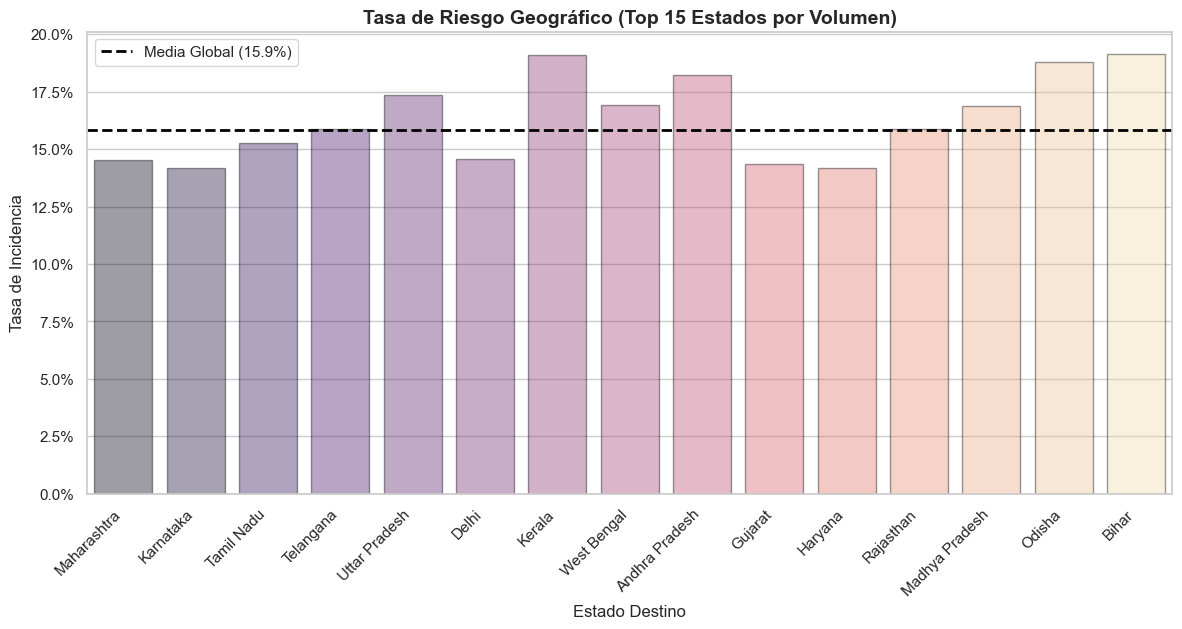

In [157]:

# 2.11. Análisis Visual: Tasa de Incidencia por Estado (Top 15 por volumen)
# Calculamos el % de incidencia y el total de pedidos
stats_estado = df_eda.groupby('ship-state').agg(Total_Pedidos=('Es_Incidencia', 'count'),Tasa_Incidencia=('Es_Incidencia', 'mean')
).sort_values(by='Total_Pedidos', ascending=False)

top_15 = stats_estado.head(15).index

plt.figure(figsize=(14, 6))
data_plot = stats_estado.loc[top_15].reset_index()

# Gráfico de barras para la tasa de incidencia
sns.barplot(data=data_plot, x='ship-state', y='Tasa_Incidencia', palette='magma', edgecolor='black', alpha=0.4)

# Añadimos una línea base con la media global de incidencias para comparar
media_global = df_eda['Es_Incidencia'].mean()
plt.axhline(media_global, color='black', linestyle='--', linewidth=2, label=f'Media Global ({media_global:.1%})')

plt.title('Tasa de Riesgo Geográfico (Top 15 Estados por Volumen)', fontsize=14, weight='bold')
plt.ylabel('Tasa de Incidencia')
plt.xlabel('Estado Destino')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
plt.legend()

guardar_imagen(plt, "15_riesgo_geografico_Estado")
plt.show()



C:\Users\jovic\AppData\Local\Temp\ipykernel_104788\2935910623.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\jovic\AppData\Local\Temp\ipykernel_104788\2935910623.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


📸 Imagen exportada con éxito: ../reports/figuras/15_riesgo_geografico_Estado_Volumen.png


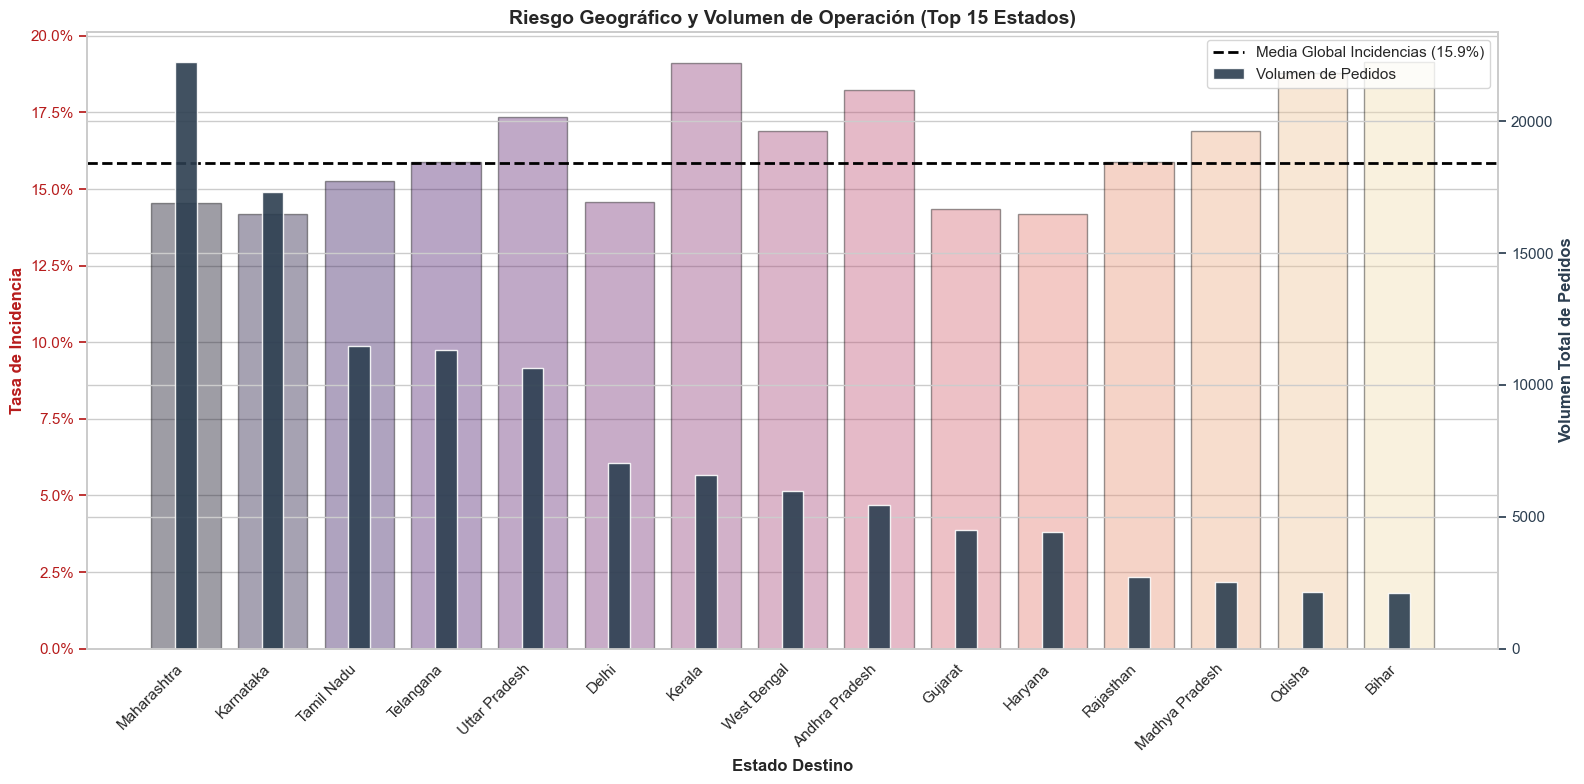

In [158]:
# 2.11. Análisis Visual: Tasa de Incidencia vs Volumen  y (Top 15 Estados)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos el % de incidencia y el total de pedidos
stats_estado = df_eda.groupby('ship-state').agg(
    Total_Pedidos=('Es_Incidencia', 'count'),
    Tasa_Incidencia=('Es_Incidencia', 'mean')
).sort_values(by='Total_Pedidos', ascending=False)

top_15 = stats_estado.head(15).index
data_plot = stats_estado.loc[top_15].reset_index()

# 2. Configuración de la figura y el eje principal (Izquierdo)
fig, ax1 = plt.subplots(figsize=(16, 8))

# Gráfico de barras ANCHAS para la tasa de incidencia (Fondo)
sns.barplot(
    data=data_plot, x='ship-state', y='Tasa_Incidencia', 
    palette='magma', edgecolor='black', alpha=0.4, ax=ax1, zorder=1
)

# 3. Creación del segundo eje (Derecho) compartiendo el eje X
ax2 = ax1.twinx()

# Gráfico de barras ESTRECHAS para el volumen (Superpuesto)
ax2.bar(
    data_plot['ship-state'], data_plot['Total_Pedidos'], 
    width=0.25, color='#2c3e50', alpha=0.9, zorder=2, label='Volumen de Pedidos'
)

# 4. Añadimos la línea base global en el eje de la tasa (ax1)
media_global = df_eda['Es_Incidencia'].mean()
ax1.axhline(
    media_global, color='black', linestyle='--', linewidth=2, 
    label=f'Media Global Incidencias ({media_global:.1%})'
)

# 5. Formateo de Títulos y Ejes
ax1.set_title('Riesgo Geográfico y Volumen de Operación (Top 15 Estados)', fontsize=14, weight='bold')
ax1.set_xlabel('Estado Destino', weight='bold')

# Eje Izquierdo (Tasa)
ax1.set_ylabel('Tasa de Incidencia', color='#b71c1c', weight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
ax1.tick_params(axis='y', colors='#b71c1c')

# Eje Derecho (Volumen)
ax2.set_ylabel('Volumen Total de Pedidos', color='#2c3e50', weight='bold')
ax2.tick_params(axis='y', colors='#2c3e50')

# Rotación de etiquetas del eje X
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# 6. Unificación de Leyendas (Combinar leyendas de ax1 y ax2)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout() # Evita que se corten los nombres de los estados

# Guardando imagen
guardar_imagen(plt, "15_riesgo_geografico_Estado_Volumen")
plt.show()

**Bloque 3:** Análisis Geográfico Monetario y Optimización de Stock* (generación de ingresos)  


***3.A. Densidad Monetaria y Ticket Medio por Región***

* **Objetivo:** Cuantificar la distribución del flujo de caja absoluto y determinar el valor promedio de transacción (AOV) a nivel estatal para identificar qué regiones concentran el verdadero valor financiero del negocio, distinguiendo entre volumen masivo y rentabilidad por pedido.

* **Acción:** Ejecutar una agregación matricial mediante `.groupby()` sobre la variable geográfica refinada (`ship-state`), aplicando funciones de agregación simultáneas (`.agg()`) para calcular la suma total (`sum`) de la columna `Amount`, el promedio (`mean`) para obtener el AOV, y el recuento de registros (`count`) para establecer el volumen crítico de pedidos.


In [159]:
# 3.A CÁLCULO DE DENSIDAD MONETARIA Y TICKET MEDIO (AOV)
#----------------------------------------------------------------
# 3.1. Agrupamos por estado y calculamos las 3 métricas clave en una sola línea
df_finanzas_geograficas = df_eda.groupby('ship-state').agg(
    Total_Pedidos=('Amount', 'count'),       # Volumen de carga logística
    Ingresos_Totales=('Amount', 'sum'),      # Flujo de caja absoluto
    Ticket_Medio=('Amount', 'mean')          # Calidad de la compra (AOV)
).reset_index()

display(df_finanzas_geograficas)

,ship-state,Total_Pedidos,Ingresos_Totales,Ticket_Medio
0,Andaman and Nicobar Islands,243,158723.62,653.183621
1,Andhra Pradesh,5055,3219831.72,636.959786
2,Apo Army Post Office,0,0.00,NaN
3,Arunachal Pradesh,140,98265.00,701.892857
4,Assam,1548,1018136.20,657.710724
5,Bihar,1963,1415613.32,721.147896
6,Chandigarh,318,211740.67,665.851164
7,Chhattisgarh,864,570485.83,660.284525
8,Dadra and Nagar Haveli,62,42138.92,679.660000
9,Delhi,6644,4393522.41,661.276702


In [160]:

#....
# 3.A CÁLCULO DE DENSIDAD MONETARIA Y TICKET MEDIO (AOV)
#----------------------------------------------------------------


# 3.2. Limpiamos posibles estados sin ventas registradas (nulos en Amount)
df_finanzas_geograficas = df_finanzas_geograficas.dropna(subset=['Ticket_Medio'])

# 3.3. Ordenamos por Ticket Medio descendente para ver quién compra más caro
df_finanzas_geograficas = df_finanzas_geograficas.sort_values(by='Ticket_Medio', ascending=False)

# 3.4. Mostramos el Top 10 de estados con mayor Ticket Medio
print("📊 TOP 10 ESTADOS POR CALIDAD DE MARGEN (Ticket Medio más alto):")
print("-" * 65)
# Usamos un formato visual para que los números grandes se lean fácil
format_dict = {'Total_Pedidos': '{:,.0f}', 'Ingresos_Totales': '₹{:,.2f}', 'Ticket_Medio': '₹{:,.2f}'}
display(df_finanzas_geograficas.head(10).style.format(format_dict))

# 3.5. Guardamos esta tabla mejorada como base para el siguiente paso
# (Se queda en memoria para el gráfico de cuadrantes 3.2)

📊 TOP 10 ESTADOS POR CALIDAD DE MARGEN (Ticket Medio más alto):
-----------------------------------------------------------------


,ship-state,Total_Pedidos,Ingresos_Totales,Ticket_Medio
18,Ladakh,42,"₹38,388.43",₹914.01
25,Nagaland,182,"₹145,055.67",₹797.01
19,Lakshadweep,4,"₹3,175.29",₹793.82
30,Sikkim,190,"₹140,828.66",₹741.20
5,Bihar,"1,963","₹1,415,613.32",₹721.15
22,Manipur,301,"₹213,981.99",₹710.90
14,Jammu and Kashmir,649,"₹456,932.74",₹704.06
3,Arunachal Pradesh,140,"₹98,265.00",₹701.89
13,Himachal Pradesh,724,"₹503,364.51",₹695.25
29,Rajasthan,"2,535","₹1,761,131.16",₹694.73


C:\Users\jovic\AppData\Local\Temp\ipykernel_104788\1405663226.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


📸 Imagen exportada con éxito: ../reports/figuras/16_pareto_ingresos_estados.png


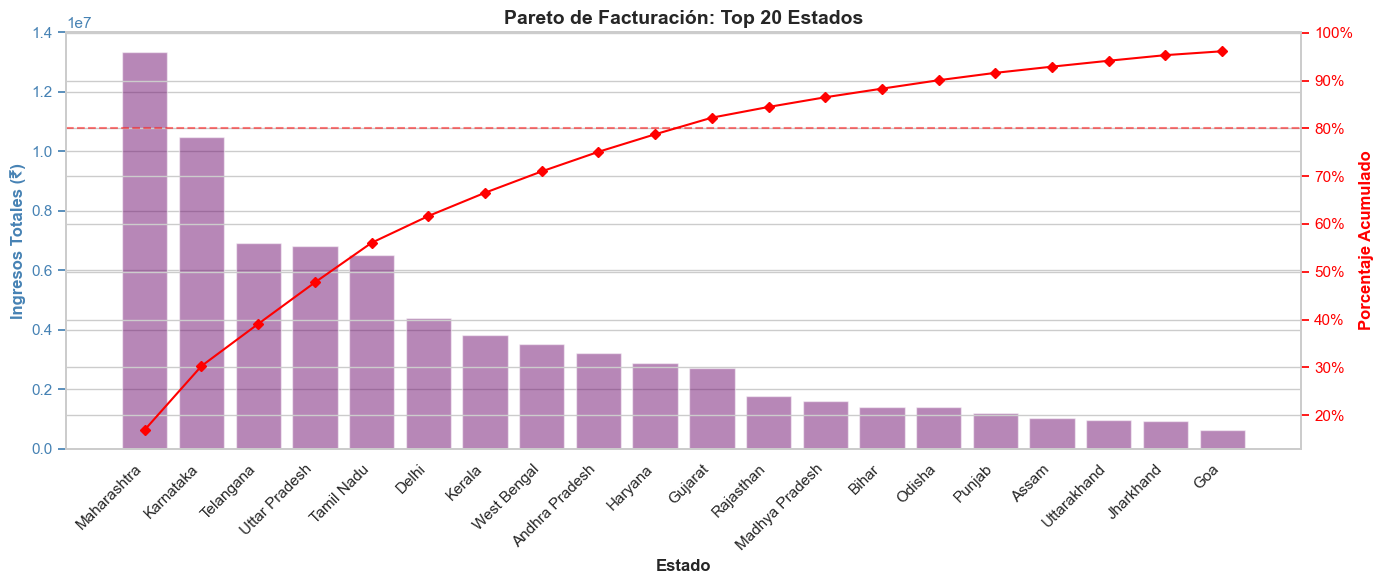

In [161]:
#....
# 3.A CÁLCULO DE DENSIDAD MONETARIA Y TICKET MEDIO (AOV)
#----------------------------------------------------------------

# 3.6. Generamos Pareto para revisar la regla del 80/20:

# confirmar si un puñado de estados están sosteniendo el 80% de toda 
# la facturación de la empresa.

#       --- PARETO DE INGRESOS POR ESTADO ---

#   1. Preparamos los datos: Ordenamos por volumen de ingresos de mayor a menor
df_pareto = df_finanzas_geograficas.sort_values(by='Ingresos_Totales', ascending=False).reset_index(drop=True)

#   2. Calculamos el porcentaje acumulado (la línea del Pareto)
df_pareto['Porcentaje_Acumulado'] = df_pareto['Ingresos_Totales'].cumsum() / df_pareto['Ingresos_Totales'].sum() * 100

# Nos quedamos con el Top 20 para que sea legible
df_pareto_top = df_pareto.head(20)

#   3. Dibujamos la figura
fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras: Ingresos Absolutos
sns.barplot(data=df_pareto_top, x='ship-state', y='Ingresos_Totales', color='purple', ax=ax1,alpha=0.5)
ax1.set_title('Pareto de Facturación: Top 20 Estados', fontsize=14, weight='bold')
ax1.set_xlabel('Estado', weight='bold')
ax1.set_ylabel('Ingresos Totales (₹)', color='steelblue', weight='bold')
ax1.tick_params(axis='y', colors='steelblue')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

#   4. Eje Secundario: Línea de Porcentaje Acumulado
ax2 = ax1.twinx()
ax2.plot(df_pareto_top['ship-state'], df_pareto_top['Porcentaje_Acumulado'], color='red', marker='D', ms=5)
ax2.axhline(80, color='red', linestyle='--', alpha=0.5) # Línea del 80%
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel('Porcentaje Acumulado', color='red', weight='bold')
ax2.tick_params(axis='y', colors='red')

plt.tight_layout()
guardar_imagen(plt,"16_pareto_ingresos_estados")
plt.show()

In [162]:
#....
# 3.A CÁLCULO DE DENSIDAD MONETARIA Y TICKET MEDIO (AOV)
#----------------------------------------------------------------

# 3.7. --- CUADRO 2: RESUMEN MACRO DEL NEGOCIO ---

total_estados = df_finanzas_geograficas.shape[0]
total_pedidos_global = df_finanzas_geograficas['Total_Pedidos'].sum()
total_ingresos_global = df_finanzas_geograficas['Ingresos_Totales'].sum()
ticket_medio_global = total_ingresos_global / total_pedidos_global

df_resumen_macro = pd.DataFrame({
    'Métrica': ['Total Estados Operativos', 'Volumen Total (Pedidos)', 'Facturación Total (₹)', 'Ticket Medio Global (AOV)'],
    'Valor': [
        f"{total_estados}",
        f"{total_pedidos_global:,.0f}",
        f"₹{total_ingresos_global:,.2f}",
        f"₹{ticket_medio_global:,.2f}"
    ]
})

print("Resumen Global del Negocio")
display(df_resumen_macro.style.hide(axis='index'))
print("\n")


Resumen Global del Negocio


Métrica,Valor
Total Estados Operativos,37
Volumen Total (Pedidos),"121,180"
Facturación Total (₹),"₹78,592,678.30"
Ticket Medio Global (AOV),₹648.56


In [163]:

#....
# 3.A CÁLCULO DE DENSIDAD MONETARIA Y TICKET MEDIO (AOV)
#----------------------------------------------------------------

# 3.8. --- ANÁLISIS DE PARETO + FRONTERA DE EXPANSIÓN ---

#   1. Encontramos cuántos estados forman exactamente el 80% de los ingresos
# Buscamos el primer índice donde el acumulado supera el 80%
indice_80_porciento = df_pareto[df_pareto['Porcentaje_Acumulado'] >= 80].index[0]
cantidad_estados_core = indice_80_porciento + 1 # +1 porque el índice empieza en 0

#   2. Le sumamos los 5 estados adicionales que pediste
cantidad_mostrar = cantidad_estados_core + 5

#   3. Cortamos el DataFrame exacto
df_pareto_estrategico = df_pareto.head(cantidad_mostrar).copy()

#   4. MEJORA: Etiquetamos estratégicamente a qué grupo pertenece cada uno
df_pareto_estrategico['Rol_Estrategico'] = [
    'Núcleo Principal (80%)' if i <= indice_80_porciento else 'Frontera de Expansión (+5)' 
    for i in range(cantidad_mostrar)
]
import pandas as pd

# 
# MEJORA VISUAL DEL CUADRO DE PARETO (Núcleo + Frontera)
# ---------------------------------------------------------------
print("Estados principales por Ingresos Totales:Nucleo 80% Pareto y Expansión")
print("-" * 80)

formato_pareto = {
    'Total_Pedidos': '{:,.0f}', 
    'Ingresos_Totales': '₹{:,.2f}', 
    'Ticket_Medio': '₹{:,.2f}',
    'Porcentaje_Acumulado': '{:.2f}%'
}

estilos_pareto = [
    {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('text-align', 'center'), ('font-size', '13px')]},
    {'selector': 'td', 'props': [('text-align', 'right'), ('font-size', '13px')]}
]

# Renderizamos ocultando el índice e inyectando un gradiente de color
display(
    df_pareto_estrategico.style
    .format(formato_pareto)
    .hide(axis='index')
    .set_table_styles(estilos_pareto)
    .background_gradient(subset=['Ingresos_Totales'], cmap='Greens')
)


Estados principales por Ingresos Totales:Nucleo 80% Pareto y Expansión
--------------------------------------------------------------------------------


ship-state,Total_Pedidos,Ingresos_Totales,Ticket_Medio,Porcentaje_Acumulado,Rol_Estrategico
Maharashtra,"21,073","₹13,335,534.14",₹632.83,16.97%,Núcleo Principal (80%)
Karnataka,"16,394","₹10,481,114.37",₹639.33,30.30%,Núcleo Principal (80%)
Telangana,"10,637","₹6,916,615.65",₹650.24,39.10%,Núcleo Principal (80%)
Uttar Pradesh,"9,947","₹6,816,642.08",₹685.30,47.78%,Núcleo Principal (80%)
Tamil Nadu,"10,809","₹6,515,650.11",₹602.80,56.07%,Núcleo Principal (80%)
Delhi,"6,644","₹4,393,522.41",₹661.28,61.66%,Núcleo Principal (80%)
Kerala,"6,151","₹3,830,227.58",₹622.70,66.53%,Núcleo Principal (80%)
West Bengal,"5,547","₹3,507,880.44",₹632.39,71.00%,Núcleo Principal (80%)
Andhra Pradesh,"5,055","₹3,219,831.72",₹636.96,75.09%,Núcleo Principal (80%)
Haryana,"4,188","₹2,882,092.99",₹688.18,78.76%,Núcleo Principal (80%)


In [164]:
#....
# 3.A CÁLCULO DE DENSIDAD MONETARIA Y TICKET MEDIO (AOV)
#----------------------------------------------------------------

# 3.9 --- EXPORTACIÓN MULTI-HOJA DEL REPORTE EJECUTIVO ---

# 1. Rutas
ruta_reportes = os.path.join('..', 'reports')
os.makedirs(ruta_reportes, exist_ok=True)
ruta_excel = os.path.join(ruta_reportes, 'reporte_geografico_ventas_pareto_completo.xlsx')

# 2. Usamos ExcelWriter de Pandas para manejar múltiples hojas
# Nota: Necesitamos tener instalada la librería 'openpyxl' (hacemos !pip install openpyxl al inicio del libro)
with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    
    # HOJA 1: El Resumen Estratégico (Núcleo + Frontera de Expansión)
    # Lo pasamos sin el índice numérico automático de Pandas
    df_pareto_estrategico.to_excel(writer, sheet_name='Resumen Estratégico', index=False)
    
    # HOJA 2: Toda la base de datos de estados para consulta profunda
    df_pareto.to_excel(writer, sheet_name='Pareto Completo', index=False)

print(f" Reporte Multi-Hoja guardado con éxito en:")
print(f" {os.path.abspath(ruta_excel)}")

 Reporte Multi-Hoja guardado con éxito en:
 c:\Users\jovic\JCProjectsDA\JC_EDA_ProyectoFinal\proyecto-final-analytics\reports\reporte_geografico_ventas_pareto_completo.xlsx


El resumen global confirma una alta concentración de nuestro flujo de caja: un grupo reducido de 11 estados conforma el "Núcleo Principal", sosteniendo el 80% de toda la facturación de la compañía.

Sin embargo, el hallazgo principal es la estabilidad del Ticket Medio (AOV) a través de todas las regiones (fluctuando en una estrecha franja de ₹600 - ₹720). Esto desmiente la noción de que los estados con menos ventas tengan menor poder adquisitivo. A nivel operativo, esto significa que el esfuerzo logístico de procesar y enviar un pedido nos reporta prácticamente el mismo volumen económico independientemente de si va a un estado núcleo (ej. Maharashtra) o a la "Frontera de Expansión" (ej. Bihar o Rajasthan).  

Esta predictibilidad garantiza que cualquier esfuerzo de penetración en nuevas zonas tendrá un Retorno de Inversión (ROI) seguro y escalable.



**3.B.Análisis de Expansión Territorial y Liquidez de Inventario**

* **Objetivo:** Visualizar la dispersión entre el volumen operativo y el Ticket Medio para validar si el comportamiento de precios se mantiene estable a gran escala, o si existen anomalías (positivas o negativas). A partir de esto, confirmar qué estados de baja penetración logística (bajo volumen) mantienen la rentabilidad estándar, convirtiéndolos en candidatos seguros para la expansión.
* **Acción:** Desarrollar un gráfico de dispersión (Scatter Plot) intersecando el Volumen Total de Pedidos (Eje X) frente al Average Order Value (Eje Y). Segmentar el plano mediante medianas para identificar visualmente la concentración horizontal (estabilidad de precios) y aislar las zonas de oportunidad en el cuadrante de bajo volumen logístico.



📸 Imagen exportada con éxito: ../reports/figuras/17_matriz_cuadrantes_territoriales.png


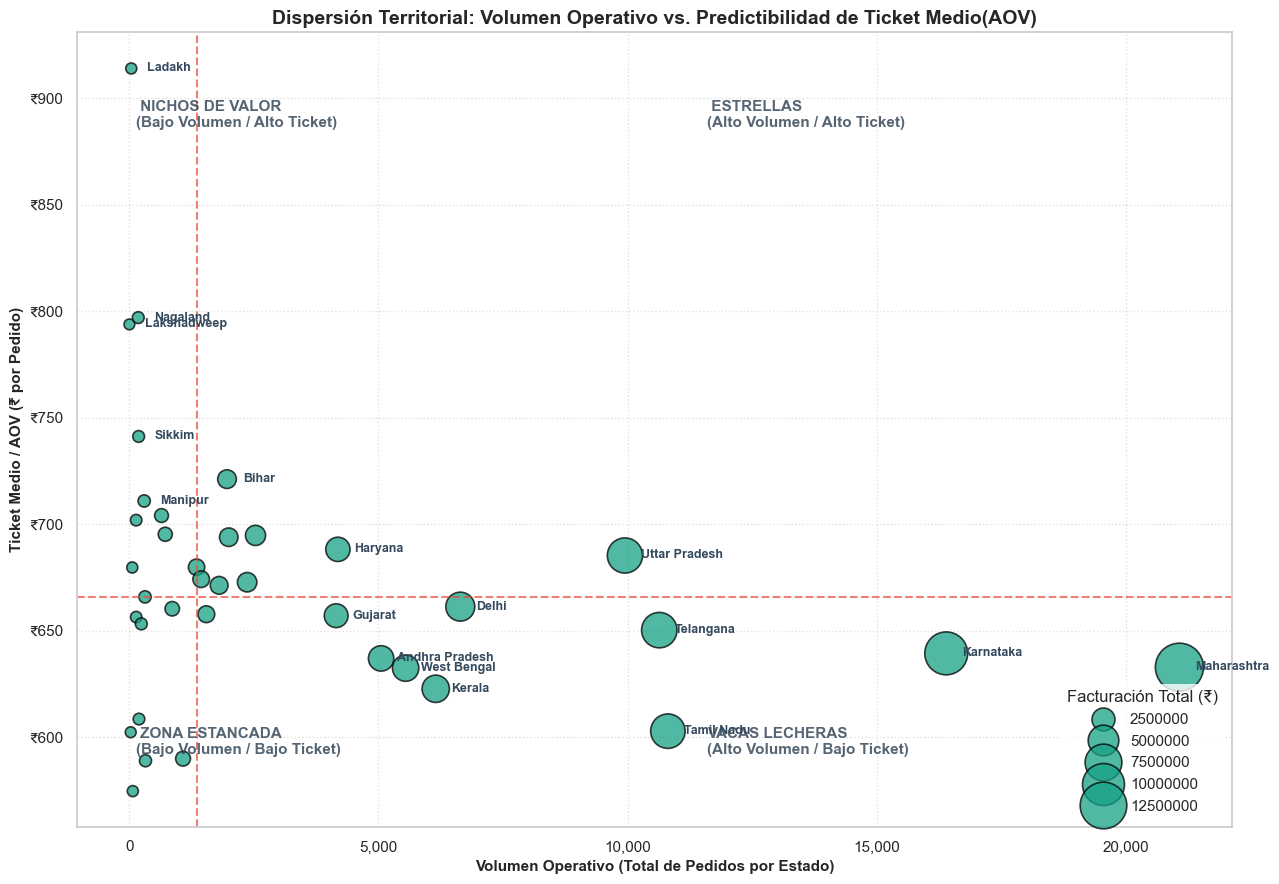

In [165]:
#**3.B. Análisis de Expansión Territorial y Liquidez de Inventario**
#----------------------------------------------------------------------


# --3.10 Mapa de Expansión: Validación de Rentabilidad y Mercados Desatendidos ---

# 1. Configuración del entorno visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(13, 9))

# 2. Definición de umbrales matemáticos (Medianas) para segmentar el plano
mediana_pedidos = df_finanzas_geograficas['Total_Pedidos'].median()
mediana_ticket = df_finanzas_geograficas['Ticket_Medio'].median()

# 3. Proyección del Scatter Plot (Gráfico de Dispersión)
# El tamaño (s) de las burbujas representa los Ingresos Totales para añadir la 3ª dimensión financiera
sns.scatterplot(
    data=df_finanzas_geograficas, 
    x='Total_Pedidos', 
    y='Ticket_Medio', 
    size='Ingresos_Totales', 
    sizes=(60, 1200), 
    alpha=0.75, 
    color='#16a085',
    edgecolor='black',
    linewidth=1.2
)

# 4. Trazado de las fronteras de los cuadrantes estratégicos basados en medianas
plt.axvline(mediana_pedidos, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axhline(mediana_ticket, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7)

# 5. Rotulación estratégica de los 4 Cuadrantes de Oportunidad Comercial
max_pedidos = df_finanzas_geograficas['Total_Pedidos'].max()
max_ticket = df_finanzas_geograficas['Ticket_Medio'].max()
min_ticket = df_finanzas_geograficas['Ticket_Medio'].min()

plt.text(max_pedidos * 0.55, max_ticket * 0.97, ' ESTRELLAS\n(Alto Volumen / Alto Ticket)', fontsize=11, color='#2c3e50', weight='bold', alpha=0.8)
plt.text(mediana_pedidos * 0.1, max_ticket * 0.97, ' NICHOS DE VALOR\n(Bajo Volumen / Alto Ticket)', fontsize=11, color='#2c3e50', weight='bold', alpha=0.8)
plt.text(max_pedidos * 0.55, min_ticket * 1.03, 'VACAS LECHERAS\n(Alto Volumen / Bajo Ticket)', fontsize=11, color='#2c3e50', weight='bold', alpha=0.8)
plt.text(mediana_pedidos * 0.1, min_ticket * 1.03, ' ZONA ESTANCADA\n(Bajo Volumen / Bajo Ticket)', fontsize=11, color='#2c3e50', weight='bold', alpha=0.8)

# 6. Etiquetado inteligente de Estados Clave (Evitamos saturar el gráfico)
# Rotulamos estados con alto volumen relativo o que superen el percentil 85 de Ticket Medio
umbral_alto_ticket = df_finanzas_geograficas['Ticket_Medio'].quantile(0.85)

for i in range(df_finanzas_geograficas.shape[0]):
    row = df_finanzas_geograficas.iloc[i]
    if row['Total_Pedidos'] > mediana_pedidos * 2.5 or row['Ticket_Medio'] > umbral_alto_ticket:
        plt.text(
            row['Total_Pedidos'] + (max_pedidos * 0.015), 
            row['Ticket_Medio'], 
            row['ship-state'], 
            horizontalalignment='left', 
            verticalalignment='center',
            size=9, 
            color='#34495e', 
            weight='semibold'
        )

# 7. Formateo y personalización ejecutiva de los ejes
plt.title('Dispersión Territorial: Volumen Operativo vs. Predictibilidad de Ticket Medio(AOV)', fontsize=14, weight='bold')
plt.xlabel('Volumen Operativo (Total de Pedidos por Estado)', fontsize=11, weight='bold')
plt.ylabel('Ticket Medio / AOV (₹ por Pedido)', fontsize=11, weight='bold')

# Aplicamos el formato de moneda (₹) y miles a los ejes
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Ajuste de la leyenda y la cuadrícula
plt.legend(title='Facturación Total (₹)', loc='lower right', frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# 8. Exportación segura de la figura (antes de plt.show)
guardar_imagen(plt, "17_matriz_cuadrantes_territoriales")
plt.show()

In [166]:
df_finanzas_geograficas.sample(2).T

,7,34
ship-state,Chhattisgarh,Unknown
Total_Pedidos,864,31
Ingresos_Totales,570485.83,18671.0
Ticket_Medio,660.284525,602.290323


In [167]:
#....
#**3.B. Análisis de Expansión Territorial y Liquidez de Inventario**
#----------------------------------------------------------------------
#3.11 Indagación y evaluación de total población vs Ingresos por ship-state. 
# enriquecemos el dataset con la demografía, calculamos los índices sin sesgos
#  de texto, renombramos la columna a Pedidos por 100k Hab y extraemos una muestra 
# combinada (Top y Bottom) para observar la dispersión bruta de los datos.
#
# Parte I: I
 # 1. Rutas
ruta_diccionarios = os.path.join('..', 'data', 'raw') # O en reports/tablas dependiendo de tu estructura
os.makedirs(ruta_diccionarios, exist_ok=True)
ruta_csv_poblacion = os.path.join(ruta_diccionarios, 'india_states_population_raw.csv')

# 2. Carga del CSV
df_poblacion_raw = pd.read_csv(ruta_csv_poblacion)

# 3. Transformación del dataframe en un diccionario de mapeo
# Usamos zip para vincular las dos columnas
diccionario_poblacion = dict(zip(df_poblacion_raw['ship-state'], df_poblacion_raw['Poblacion_Estimada']))

# 4. Inyección en tu DataFrame principal
df_finanzas_geograficas['Poblacion'] = df_finanzas_geograficas['ship-state'].map(diccionario_poblacion)

print("✅ Datos de población mapeados directamente desde la fuente CSV externa.")

#Parte II:

# 1. Aseguramos denominadores globales basados en el dataset mapeado
poblacion_total_mapeada = df_finanzas_geograficas['Poblacion'].sum()
ingresos_totales_global = df_finanzas_geograficas['Ingresos_Totales'].sum()

# 2. Generación de métricas relativas y normalización demográfica
df_finanzas_geograficas['%_Poblacion_Total'] = (df_finanzas_geograficas['Poblacion'] / poblacion_total_mapeada) * 100
df_finanzas_geograficas['%_Ingresos_Total'] = (df_finanzas_geograficas['Ingresos_Totales'] / ingresos_totales_global) * 100

# Cálculo de Pedidos por cada 100,000 habitantes (Columna renombrada a petición de negocio)
df_finanzas_geograficas['Pedidos por 100k Hab'] = (df_finanzas_geograficas['Total_Pedidos'] / df_finanzas_geograficas['Poblacion']) * 100000

# Índice de Penetración Relativa (% Ingresos / % Población)
df_finanzas_geograficas['Indice_Penetracion_Relativa'] = (
    df_finanzas_geograficas['%_Ingresos_Total'] / df_finanzas_geograficas['%_Poblacion_Total']
)

# 3. Preparación de una muestra neutral (Top 5 y Bottom 5 por índice de penetración)
df_ordenado = df_finanzas_geograficas.sort_values(by='Indice_Penetracion_Relativa', ascending=False)

#muestra al final nan => df_muestra_contrastada = pd.concat([df_ordenado.head(5), df_ordenado.tail(5)])
# Extraemos el Top 5 (los NaN están abajo, así que el head(5) es seguro)
top_5 = df_ordenado.head(5)

#Para el Bottom 5, filtramos los NaN sobre el DataFrame ya ordenado
#Así el tail(5) tomará los 5 valores numéricos más bajos reales
bottom_5 = df_ordenado[df_ordenado['Indice_Penetracion_Relativa'].notna()].tail(5)

#Concatenamos la muestra neutral contrastada
df_muestra_contrastada = pd.concat([top_5, bottom_5])


# 4. Renderizado con formato ejecutivo
formato_neutral = {
    'Poblacion': '{:,.0f}',
    'Ingresos_Totales': '₹{:,.2f}',
    '%_Poblacion_Total': '{:.2f}%',
    '%_Ingresos_Total': '{:.2f}%',
    'Pedidos por 100k Hab': '{:.2f}',
    'Indice_Penetracion_Relativa': '{:.2f}'
}

estilos_neutral = [
    {'selector': 'th', 'props': [('background-color', '#455a64'), ('color', 'white'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'right')]}
]

print(" Reporte Geográfico:Muestra de extremos en penetración relativa.")

display(
    df_muestra_contrastada[[
        'ship-state', 'Poblacion', '%_Poblacion_Total', 
        'Ingresos_Totales', '%_Ingresos_Total', 'Pedidos por 100k Hab', 'Indice_Penetracion_Relativa'
    ]]
    .style
    .format(formato_neutral)
    .hide(axis='index')
    .set_table_styles(estilos_neutral)
)

✅ Datos de población mapeados directamente desde la fuente CSV externa.
 Reporte Geográfico:Muestra de extremos en penetración relativa.


ship-state,Poblacion,%_Poblacion_Total,Ingresos_Totales,%_Ingresos_Total,Pedidos por 100k Hab,Indice_Penetracion_Relativa
Goa,"1,500,000",0.10%,"₹637,685.85",0.81%,72.07,7.96
Andaman and Nicobar Islands,"400,000",0.03%,"₹158,723.62",0.20%,60.75,7.43
Sikkim,"690,000",0.05%,"₹140,828.66",0.18%,27.54,3.82
Delhi,"22,200,000",1.51%,"₹4,393,522.41",5.59%,29.93,3.70
Telangana,"38,200,000",2.60%,"₹6,916,615.65",8.80%,27.85,3.39
Rajasthan,"81,800,000",5.56%,"₹1,761,131.16",2.24%,3.10,0.40
Chhattisgarh,"30,900,000",2.10%,"₹570,485.83",0.73%,2.80,0.35
Madhya Pradesh,"87,600,000",5.96%,"₹1,592,382.98",2.03%,2.70,0.34
Bihar,"128,500,000",8.74%,"₹1,415,613.32",1.80%,1.53,0.21
Himachal Pradesh,"75,000,000",5.10%,"₹503,364.51",0.64%,0.97,0.13


💡 Análisis Intermedio de Dispersión Demográfica

La muestra contrastada de extremos revela una asimetría macroeconómica profunda en el comportamiento del dataset. Observamos estados con un volumen demográfico masivo cuyas participaciones en la facturación total (`%_Ingresos_Total`) se encuentran drásticamente por debajo de su peso poblacional real (`%_Poblacion_Total`), resultando en Índices de Penetración Relativa muy inferiores a la unidad (1.0). En el extremo opuesto, regiones con menor densidad poblacional registran una concentración de ingresos hiper-eficiente.

**Justificación del Análisis Estadístico Compuesto:**
Para determinar si estas variaciones son anomalías aisladas o si representan un patrón estructural de comportamiento entre el mercado maduro y el resto del país, se hace estrictamente necesario aislar las métricas descriptivas fundamentales (Mínimo, Máximo, Mediana y Media). Compararemos los estadísticos del **Total Nacional** frente a los **11 estados que conforman el 80% del Core de Pareto**, estableciendo así un marco matemático de referencia (*benchmark*) antes de proponer cualquier asignación de presupuesto comercial.

In [ ]:
#...
#**3.B. Análisis de Expansión Territorial y Liquidez de Inventario**
#----------------------------------------------------------------------
#
# 3.12 Extracción de Estadísticas con formato
# Aislamiento de datos del núcleo
estados_core_11 = df_pareto_estrategico.head(11)['ship-state'].tolist()
df_core_pareto = df_finanzas_geograficas[df_finanzas_geograficas['ship-state'].isin(estados_core_11)]

# Cálculo de agregaciones descriptivas
stats_total = df_finanzas_geograficas[['Indice_Penetracion_Relativa', 'Poblacion', '%_Poblacion_Total']].agg(['min', 'max', 'median', 'mean'])
stats_core = df_core_pareto[['Indice_Penetracion_Relativa', 'Poblacion', '%_Poblacion_Total']].agg(['min', 'max', 'median', 'mean'])

#3.12.1 Agregado demográfico  Macro. 
#--------------------------------------------------------------------------

import pandas as pd

print("Cuadro de control: Masa Demográfica Total y Rendimiento Comercial ()")

# 1. Extracción de los sumatorios para el Total Nacional
pop_abs_total = df_finanzas_geograficas['Poblacion'].sum()
pop_rel_total = df_finanzas_geograficas['%_Poblacion_Total'].sum()
ingresos_abs_total = df_finanzas_geograficas['Ingresos_Totales'].sum()
ingresos_rel_total = df_finanzas_geograficas['%_Ingresos_Total'].sum()
pedidos_abs_total = df_finanzas_geograficas['Total_Pedidos'].sum()
pedidos_rel_total = 100.0  # Representa el 100% de la operación

# 2. Extracción de los sumatorios para el Núcleo (Core Pareto)
pop_abs_core = df_core_pareto['Poblacion'].sum()
pop_rel_core = df_core_pareto['%_Poblacion_Total'].sum()
ingresos_abs_core = df_core_pareto['Ingresos_Totales'].sum()
ingresos_rel_core = df_core_pareto['%_Ingresos_Total'].sum()
pedidos_abs_core = df_core_pareto['Total_Pedidos'].sum()
pedidos_rel_core = (pedidos_abs_core / pedidos_abs_total) * 100  # Cálculo de su peso operativo

# 3. Construcción del DataFrame estructurado con las nuevas columnas
df_macro_sumatoria = pd.DataFrame({
    'Grupo de Análisis': ['Total Nacional (Mercado Completo)', 'Núcleo Pareto (11 Estados Core)'],
    'Población Absoluta': [pop_abs_total, pop_abs_core],
    '% Población': [pop_rel_total, pop_rel_core],
    'Ingresos Totales': [ingresos_abs_total, ingresos_abs_core],
    '% Ingresos': [ingresos_rel_total, ingresos_rel_core],
    'Total Pedidos': [pedidos_abs_total, pedidos_abs_core],
    '% Pedidos': [pedidos_rel_total, pedidos_rel_core]
})

# 4. Formateo y Estilos CSS en línea corporativos
formato_sumatoria = {
    'Población Absoluta': '{:,.0f}',
    '% Población': '{:.2f}%',
    'Ingresos Totales': '₹{:,.2f}',
    '% Ingresos': '{:.2f}%',
    'Total Pedidos': '{:,.0f}',
    '% Pedidos': '{:.2f}%'
}

estilos_sumatoria = [
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center'), ('font-size', '13px'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('font-size', '13px'), ('padding', '8px 12px')]}
]

# Definimos las columnas numéricas para alinearlas a la derecha fácilmente
columnas_numericas = ['Población Absoluta', '% Población', 'Ingresos Totales', '% Ingresos', 'Total Pedidos', '% Pedidos']

# 5. Renderizado limpio
display(
    df_macro_sumatoria.style
    .format(formato_sumatoria)
    .hide(axis='index')
    .set_table_styles(estilos_sumatoria)
    .set_properties(subset=['Grupo de Análisis'], **{'text-align': 'left'})
    .set_properties(subset=columnas_numericas, **{'text-align': 'right'})
    # Resaltamos sutilmente la fila del núcleo para el contraste de negocio
    .set_properties(subset=pd.IndexSlice[1, :], **{'font-weight': 'bold', 'background-color': '#fdf2e9'})
)
print("\n")

#3.12.2. Estadisticas de indices de penetración de la 'Población Total' de las regiones 
#de refencia y las del 80% de pareto., 
#-------------------------------------------------------------------- 
# Aislamiento de datos del núcleo
estados_core_11 = df_pareto_estrategico.head(11)['ship-state'].tolist()
df_core_pareto = df_finanzas_geograficas[df_finanzas_geograficas['ship-state'].isin(estados_core_11)]

# Cálculo de agregaciones descriptivas
stats_total = df_finanzas_geograficas[['Indice_Penetracion_Relativa', 'Poblacion', '%_Poblacion_Total']].agg(['min', 'max', 'median', 'mean'])
stats_core = df_core_pareto[['Indice_Penetracion_Relativa', 'Poblacion', '%_Poblacion_Total']].agg(['min', 'max', 'median', 'mean'])

def formatear_estadisticas_ejecutivas(df_stats):
    df_fmt = df_stats.copy()
    df_fmt['Indice_Penetracion_Relativa'] = df_fmt['Indice_Penetracion_Relativa'].apply(lambda x: f"{x:.2f}")
    df_fmt['Poblacion'] = df_fmt['Poblacion'].apply(lambda x: f"{x:,.0f}")
    df_fmt['%_Poblacion_Total'] = df_fmt['%_Poblacion_Total'].apply(lambda x: f"{x:.2f}%")
    
    df_fmt = df_fmt.rename(columns={
        'Indice_Penetracion_Relativa': 'Índice de Penetración Relativa',
        'Poblacion': 'Población Absoluta',
        '%_Poblacion_Total': 'Población Relativa (%)'
    }).T
    df_fmt.columns = ['Mínimo', 'Máximo', 'Mediana', 'Media']
    return df_fmt

estilos_stats = [
    {'selector': 'th.col_heading', 'props': [('background-color', '#f8f9fa'), ('color', '#2c3e50'), ('text-align', 'center'), ('font-size', '13px')]},
    {'selector': 'th.row_heading', 'props': [('text-align', 'left'), ('font-weight', 'bold'), ('font-size', '13px')]},
    {'selector': 'td', 'props': [('text-align', 'right'), ('padding', '6px 15px'), ('font-size', '13px')]}
]

print("Estadísticas del Total de Estados (nacional)")
display(formatear_estadisticas_ejecutivas(stats_total).style.set_table_styles(estilos_stats))
print("\n")
print("Estadísticas del Núcleo (Los 11 estados del 80% Pareto)")
display(formatear_estadisticas_ejecutivas(stats_core).style.set_table_styles(estilos_stats))


Cuadro de control: Masa Demográfica Total y Rendimiento Comercial


Grupo de Análisis,Población Absoluta,% Población,Ingresos Totales,% Ingresos,Total Pedidos,% Pedidos
Total Nacional (Mercado Completo),"1,470,960,000",100.00%,"₹78,592,678.30",100.00%,"121,180",100.00%
Núcleo Pareto (11 Estados Core),"866,000,000",58.87%,"₹64,627,763.31",82.23%,"100,598",83.02%




Estadísticas del Total de Estados (nacional)


,Mínimo,Máximo,Mediana,Media
Índice de Penetración Relativa,0.13,7.96,1.18,1.69
Población Absoluta,"70,000","241,000,000","30,900,000","40,860,000"
Población Relativa (%),0.00%,16.38%,2.10%,2.78%




Estadísticas del Núcleo (Los 11 estados del 80% Pareto)


,Mínimo,Máximo,Mediana,Media
Índice de Penetración Relativa,0.53,3.70,1.74,1.84
Población Absoluta,"22,200,000","241,000,000","68,100,000","78,727,273"
Población Relativa (%),1.51%,16.38%,4.63%,5.35%


Mira la fila de Población Absoluta (Mediana).

Total Nacional: 30.9 millones

Núcleo Pareto: 68.1 millones

El Top 11 no factura el 80% porque tengamos un marketing perfecto ahí, sino por fuerza bruta demográfica. Son estados gigantescos. De hecho, el mínimo índice de penetración dentro del "Top 11" es de 0.53 (muy por debajo del 1.0 de equilibrio). 

Esto significa que incluso dentro de nuestros "mejores estados", tenemos gigantes dormidos (como Uttar Pradesh, que tiene 241 millones de personas pero una penetración bajísima, y aun así entra al Top 5 solo por volumen puro).

📸 Imagen exportada con éxito: ../reports/figuras/18_asimetria_penetracion_territorial.png


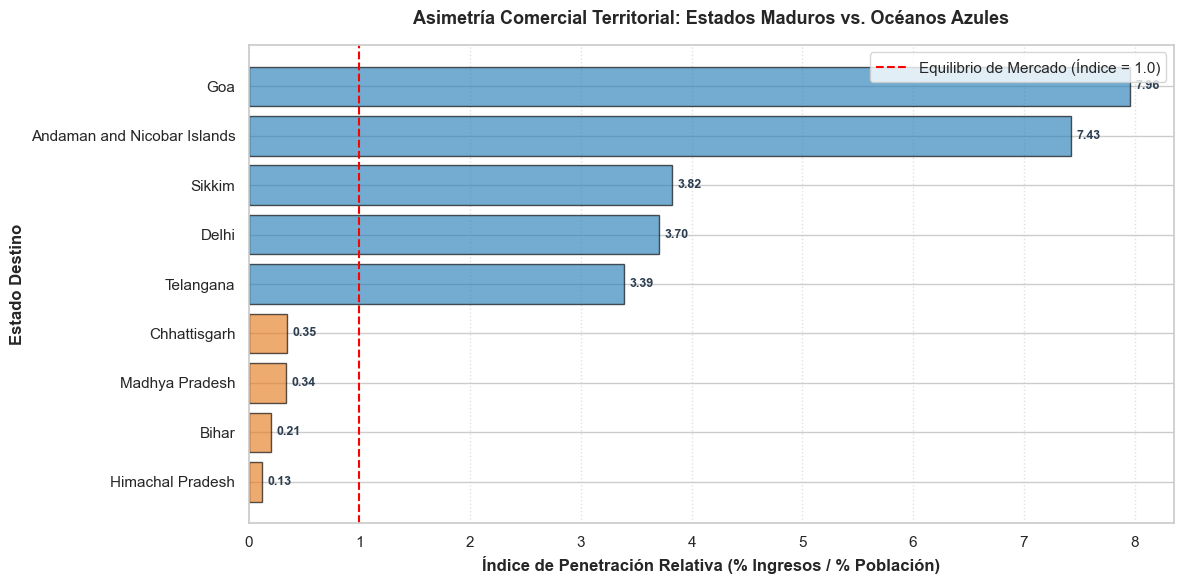

In [169]:
#...
#**3.B. Análisis de Expansión Territorial y Liquidez de Inventario**
#----------------------------------------------------------------------

# 3.13 Visualización de Contraste de Penetración (Gráfico)

#Implementamos un gráfico de barras horizontales enfocado que muestra
# los 5 estados con mayor penetración frente a los 5 con menor
# penetración, trazando la línea de equilibrio de mercado (Índice = 1.0). 
# Esto permite ver el potencial de expansión de un solo vistazo.
# 1. Preparamos los datos ordenados para el gráfico
df_grafico = pd.concat([df_ordenado.head(5), df_ordenado.tail(5)]).copy()
df_grafico = df_grafico.sort_values(by='Indice_Penetracion_Relativa', ascending=False)

# Asignamos colores condicionales: Azul para alta penetración, Naranja para mercados desatendidos
colores = ['#2980b9' if x >= 1.0 else '#e67e22' for x in df_grafico['Indice_Penetracion_Relativa']]

# 2. Construcción de la figura
plt.figure(figsize=(12, 6))
barras = plt.barh(df_grafico['ship-state'], df_grafico['Indice_Penetracion_Relativa'], color=colores, edgecolor='black', alpha=0.65)

# 3. Línea de referencia (Equilibrio de mercado: % Población == % Ingresos)
plt.axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Equilibrio de Mercado (Índice = 1.0)')

# Añadimos etiquetas de valor en las barras para facilitar la lectura rápida
for barra in barras:
    width = barra.get_width()
    plt.text(
        width + 0.05 if width >= 0 else width - 0.4, 
        barra.get_y() + barra.get_height()/2, 
        f'{width:.2f}', 
        va='center', ha='left', fontsize=9, weight='bold', color='#2c3e50'
    )

# 4. Formateo formal del gráfico
plt.title('Asimetría Comercial Territorial: Estados Maduros vs. Océanos Azules', fontsize=13, weight='bold', pad=15)
plt.xlabel('Índice de Penetración Relativa (% Ingresos / % Población)', weight='bold')
plt.ylabel('Estado Destino', weight='bold')
plt.legend(loc='upper right')
plt.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.gca().invert_yaxis() # Invierte el eje para que el índice más alto quede arriba
plt.tight_layout()

# Guardado
guardar_imagen(plt, "18_asimetria_penetracion_territorial")
plt.show()

💡 Conclusión del Análisis de Capacidad Territorial


La evaluación cruzada de las estadísticas poblacionales y de penetración revela un matiz estratégico fundamental que replantea la imagen que se tiene sobre el "Núcleo" de negocio:

El Mito de la Hiper-Eficiencia: Aunque el Core de Pareto (los 11 estados principales) sostiene el 80% de la facturación, su Mediana de Penetración Relativa (1.74) no es radicalmente superior a la mediana nacional (1.18). Esto demuestra que nuestro volumen de ingresos en el núcleo no se debe puramente a una alta saturación comercial, sino a la fuerza bruta demográfica: la mediana poblacional de estos estados (68.1M) duplica a la nacional (30.9M).

Gigantes Dormidos (Incluso en el Core): El hecho de que el índice mínimo dentro de nuestro Top 11 sea de apenas 0.53 indica que incluso dentro de los estados que más facturan (ej. Uttar Pradesh), existe una infra-penetración masiva. No hemos tocado el techo de mercado ni siquiera en nuestras zonas más fuertes.

El Diagnóstico de la Frontera: Al sumar la estabilidad del Ticket Medio (validada en el mapa de dispersión) con los mínimos absolutos de penetración nacional (índices de 0.13), confirmamos la existencia de "Océanos Azules". Son regiones con densidades poblacionales masivas donde nuestra cuota de mercado es matemáticamente irrelevante en este momento.

**3.3. Auditoría de Stock: El Índice de Inmovilización Crítica (IIC)**

**Objetivo Estratégico:**
Habiendo detectado los "Océanos Azules" demográficos (estados con altísima población pero penetración comercial marginal), el objetivo pivota hacia la optimización de activos para financiar esta expansión.

**Metodología:**
Debemos diferenciar entre un artículo de "nicho" (pocas ventas, pero poco stock) y un artículo de "riesgo" (pocas ventas, pero acaparando espacio en el almacén). Para ello, cruzaremos el **flujo transaccional histórico** (unidades vendidas) con el **saldo estático corporativo** (unidades físicas en los hubs logísticos) creando la siguiente métrica:

$$\text{IIC} = \frac{\text{Stock Físico}}{\text{Total Unidades Vendidas} + 1}$$

*(Nota: Se suma 1 al denominador para evitar indefiniciones matemáticas en SKUs con cero ventas históricas).* Esta métrica rankeará el catálogo, priorizando en alerta roja aquellos artículos (Categoría + Talla) que representan el mayor volumen de capital inmovilizado y sobrecoste de almacenamiento.

In [170]:
#
# 📦 3.3. Auditoría de Inventario y Cálculo del IIC
# -----------------------------------------------------------------------
# 1. Agrupamos el histórico sumando salidas y extrayendo la foto estática del stock

#Aplicamos  3 pasos para generar la data agrupada:

#Fase Estática: Agrupar por SKU (el identificador único real) para sacar su stock único
#  (first). Luego, sumar todos esos stocks únicos agrupándolos por Categoría y Talla.
#Fase Transaccional: Agrupar las ventas por Categoría y Talla.
#El Merge: Unir ambas realidades y calcular el IIC correcto.

# --- FASE 1: RECONSTRUCCIÓN DEL STOCK FÍSICO REAL ---
# 1.1 Aislamos el stock único por cada producto exacto (SKU)
df_stock_unico = df_eda.groupby(['SKU', 'Category', 'Size']).agg(
    Stock_Por_SKU=('Stock', 'first')
).reset_index()

# 1.2 Sumamos todos los SKUs para obtener el stock total real de la Categoría + Talla
df_stock_real = df_stock_unico.groupby(['Category', 'Size']).agg(
    Stock_Fisico_Total=('Stock_Por_SKU', 'sum')
).reset_index()


# --- FASE 2: AGREGACIÓN DEL FLUJO TRANSACCIONAL ---
df_ventas = df_eda.groupby(['Category', 'Size']).agg(
    Total_Unidades_Vendidas=('Qty', 'sum'),
    Ingresos_Historicos=('Amount', 'sum')
).reset_index()


# --- FASE 3: MERGE Y CÁLCULO DEL IIC ---
# Unimos las ventas con el stock real calculado
df_auditoria = pd.merge(df_ventas, df_stock_real, on=['Category', 'Size'], how='left')

# Limpieza de seguridad
df_auditoria['Stock_Fisico_Total'] = pd.to_numeric(df_auditoria['Stock_Fisico_Total'], errors='coerce').fillna(0)

# Cálculo del Índice (IIC) y Ticket Medio
df_auditoria['Índice_Inmovilización'] = df_auditoria['Stock_Fisico_Total'] / (df_auditoria['Total_Unidades_Vendidas'] + 1)
df_auditoria['Ticket_Medio_SKU'] = df_auditoria['Ingresos_Historicos'] / df_auditoria['Total_Unidades_Vendidas']

print("pre-visualización de df_auditoria:")
display(df_auditoria.sample(5))

# Ordenación Crítica (Mayor inmovilización arriba)
df_auditoria_ordenada = df_auditoria.sort_values(by='Índice_Inmovilización', ascending=False)



# Aislamiento del Percentil 15 Superior (La zona de Alerta Roja)
umbral_critico = df_auditoria_ordenada['Índice_Inmovilización'].quantile(0.85)
df_alerta_roja = df_auditoria_ordenada[df_auditoria_ordenada['Índice_Inmovilización'] >= umbral_critico].copy()

# --- FASE 4: RENDERIZADO  ---
formato_auditoria = {
    'Total_Unidades_Vendidas': '{:,.0f}',
    'Stock_Fisico_Total': '{:,.0f}',
    'Índice_Inmovilización': '{:.2f}',
    'Ingresos_Historicos': '₹{:,.2f}',
    'Ticket_Medio_SKU': '₹{:,.2f}'
}

estilos_auditoria = [
    {'selector': 'th', 'props': [('background-color', '#2f2954'), ('color', 'white'), ('text-align', 'center'), ('font-size', '13px'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('font-size', '13px'), ('padding', '6px 12px')]}
]

print("Auditoría de Inventario: top 15% de macro-categorías con mayor capital inmovilizado")

display(
    df_alerta_roja.style
    .format(formato_auditoria)
    .hide(axis='index')
    .set_table_styles(estilos_auditoria)
    .background_gradient(subset=['Índice_Inmovilización'], cmap='Purples')
    .set_properties(subset=['Total_Unidades_Vendidas', 'Stock_Fisico_Total', 'Índice_Inmovilización', 'Ingresos_Historicos', 'Ticket_Medio_SKU'], **{'text-align': 'right'})
)

pre-visualización de df_auditoria:


,Category,Size,Total_Unidades_Vendidas,Ingresos_Historicos,Stock_Fisico_Total,Índice_Inmovilización,Ticket_Medio_SKU
52,kurta,M,7713,3547070.45,15803.0,2.048613,459.882076
25,Set,5XL,57,67689.00,67.0,1.155172,1187.526316
26,Set,6XL,72,90418.07,61.0,0.835616,1255.806528
39,Top,XXL,1688,884321.99,1956.0,1.158082,523.887435
2,Blouse,M,138,80511.24,489.0,3.517986,583.414783


Auditoría de Inventario: top 15% de macro-categorías con mayor capital inmovilizado


Category,Size,Total_Unidades_Vendidas,Ingresos_Historicos,Stock_Fisico_Total,Índice_Inmovilización,Ticket_Medio_SKU
Blouse,Free,211,"₹80,344.01","3,556",16.77,₹380.78
Bottom,XS,26,"₹9,491.72",422,15.63,₹365.07
Blouse,XS,25,"₹9,865.10",249,9.58,₹394.60
Bottom,L,67,"₹25,031.21",624,9.18,₹373.60
Saree,Free,152,"₹123,933.76","1,283",8.39,₹815.35
Bottom,3XL,60,"₹24,332.63",366,6.00,₹405.54
Bottom,S,67,"₹22,598.76",388,5.71,₹337.29
Ethnic Dress,XS,77,"₹53,398.00",428,5.49,₹693.48
Bottom,XXL,64,"₹23,753.44",283,4.35,₹371.15


Si solo hubiéramos buscado "lo que tiene más stock", el sistema nos habría arrojado los productos súper-ventas de los que Amazon guarda 50,000 unidades porque sabe que las venderá en dos semanas.

Al usar el Índice de Inmovilización Crítica (IIC), el algoritmo ha ignorado el inventario sano y te ha puesto en bandeja de plata el inventario tóxico: ese que no es gigantesco en volumen absoluto, pero que está completamente muerto en las estanterías.

Teniendo en cuenta que la data abarca 3 meses desde el 31 Marzo 2022 a 29 Junio de 2022. 

Ejemplo: Bottom (XS)Velocidad de Venta: 26 unidades en 3 meses
 $\approx$ 8.6 unidades al mes.
 Stock Físico Real: 422 unidades.
 Tiempo de Liquidación Orgánica:$$\frac{422}{8.6} \approx 49 \text{ meses}$$

La corrección de los datos a nivel de artículo único (SKU) ha revelado el verdadero impacto de los productos de baja rotación en la cadena de suministro. Al evaluar el ritmo de las existencias, queda claro que el verdadero riesgo no está en tener un volumen alto de productos, sino en la **desconexión entre el stock disponible y su velocidad de venta**. 

Dado que el periodo analizado abarca un trimestre (3 meses), la proyección temporal implica un riesgo. 

* Combinaciones como **Blouse (Free)** (3.556 unidades estáticas frente a un ritmo de ~70 ventas mensuales) o **Bottom (XS)** (422 unidades frente a ~8,6 ventas mensuales) necesitarían **más de 4 años** para venderse de forma orgánica.
* Este inventario representa capital inmovilizado que bloquea el flujo de caja y genera un gasto continuo en costes de almacenamiento.

**Plan de Acción :**
La estrategia más eficiente no es dar por perdida la mercancía ni asumir el coste del almacén, sino transformarla en una oportunidad comercial. Estos productos estancados son el recurso ideal para lanzar campañas de promoción. 

En la siguiente sección, analizaremos si estos artículos tienen potencial en nuestros **"Gigantes Dormidos"** (regiones con un gran mercado pero desatendidas, como Bihar o Rajasthan). 

Como Alterntiva, si introducimos este inventario en esos mercados estratégicos, se podría ganar cuota de mercado con un riesgo financiero prácticamente nulo.


**3.4. Cruce Estratégico: Redistribución de Productos en Regiones Objetivo**

El análisis de rotación anterior (3.3) nos proporcionó la lista exacta de los productos con menor rendimiento: combinaciones de categoría y talla que acumulan meses o años de inventario inmovilizado en comparación con su velocidad de venta actual.

El paso final de este bloque es cruzar este listado de baja rotación con nuestros **"Gigantes Dormidos"** (los estados con menor penetración comercial identificados en el paso 3.2). 
El objetivo de esta matriz es evaluar el volumen histórico de ventas de estos productos específicos en dichas regiones.
Si las ventas allí han sido nulas o marginales, confirmaremos que estos mercados representan una oportunidad de expansión limpia.

Esto nos permitirá diseñar una estrategia de entrada eficiente: penetrar en nuevos mercados utilizando el inventario estancado como recurso promocional (mediante ofertas de lanzamiento o creación de *bundles*). 

Así, lograremos ganar cuota de mercado mientras, al mismo tiempo, liberamos espacio y capital en el sistema logístico.

In [171]:
#buscamos los last 5

last_five=df_muestra_contrastada.tail(5)['ship-state'].tolist()
print(last_five)

['Rajasthan', 'Chhattisgarh', 'Madhya Pradesh', 'Bihar', 'Himachal Pradesh']


In [172]:
# 3.4. Matriz de Redistribución Estratégica de Stock
# -------------------------------------------------------------------------
# 1. Definimos los "Gigantes Dormidos" (Mercados objetivo de alta demografía y baja penetración)
# (Ajusta esta lista si tus Bottom 5 en el paso 3.2 arrojaron otros nombres)
estados_expansion = last_five
#['Rajasthan', 'Chhattisgarh', 'Madhya Pradesh', 'Bihar', 'Himachal Pradesh']

# 2. Aislamos el Top 10 de Macro-Categorías con mayor riesgo (mayor IIC) de la tabla anterior
top_riesgo = df_alerta_roja.head(10).copy()

# Creamos una clave combinada 'Categoría + Talla' (Forzamos a string para evitar errores con variables categóricas)
top_riesgo['Macro_Categoria'] = top_riesgo['Category'].astype(str) + " (" + top_riesgo['Size'].astype(str) + ")"
lista_categorias_riesgo = top_riesgo['Macro_Categoria'].tolist()

# 3. Preparamos el dataset maestro
df_cruce = df_eda.copy()
df_cruce['Macro_Categoria'] = df_cruce['Category'].astype(str) + " (" + df_cruce['Size'].astype(str) + ")"

# 4. Filtramos la base de datos: Solo nos importan los productos tóxicos en los estados objetivo
df_target = df_cruce[
    (df_cruce['ship-state'].isin(estados_expansion)) & 
    (df_cruce['Macro_Categoria'].isin(lista_categorias_riesgo))
]

# 5. Generamos la Matriz de Asignación Comercial (Pivot Table)
matriz_oportunidad = pd.pivot_table(
    df_target, 
    values='Qty', 
    index='Macro_Categoria', 
    columns='ship-state', 
    aggfunc='sum', 
    fill_value=0 # Revelará los mercados completamente vírgenes (0 ventas)
)

# 6. Formateo y diseño ejecutivo
estilos_matriz = [
    {'selector': 'th', 'props': [('background-color', '#341539'), ('color', 'white'), ('text-align', 'center'), ('font-size', '13px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('font-size', '13px'), ('font-weight', 'bold')]}
]

print("Matriz de Asignación: ventas históricas del inventario crítico en Zonas de Expansión")

display(
    matriz_oportunidad.style
    .background_gradient(cmap='Purples', low=0, high=0.5) # Mapa de calor verde sutil
    .set_table_styles(estilos_matriz)
)

Matriz de Asignación: ventas históricas del inventario crítico en Zonas de Expansión


ship-state,Bihar,Chhattisgarh,Himachal Pradesh,Madhya Pradesh,Rajasthan
Macro_Categoria,,,,,
Blouse (Free),3,1,1,4,2
Bottom (3XL),1,0,0,2,1
Bottom (L),4,0,0,1,2
Bottom (S),0,0,0,1,0
Bottom (XS),0,0,0,0,0
Bottom (XXL),1,0,1,0,2
Ethnic Dress (XS),1,0,0,0,2
Saree (Free),6,1,0,3,3


REVISAR ##### Al visualizar la matriz de dispersión geográfica 

Resumen Ejecutivo: Bloque 3 (Auditoría de Activos y Estrategia Territorial)

Este bloque ha transformado nuestro dataset transaccional en un motor de decisión operativa. Hemos pasado de una visualización pasiva a un modelo de asignación activa mediante tres pasos críticos:

1. **Segmentación Geográfica:** Aislamiento de estados con alta densidad demográfica donde nuestra penetración comercial es marginal.
2. **Cuantificación de la Inmovilización:** Implementación del **Índice de Inmovilización Crítica (IIC)**, permitiendo identificar no solo qué productos no rotan, sino cuáles están generando un sobrecoste real de almacenamiento.
3. **Plan de Asignación Estratégica:** Definición de una ruta de entrada en mercados vírgenes mediante el uso de inventario inmovilizado como activo promocional, mitigando riesgos y optimizando el flujo de caja sin necesidad de inversión adicional.

**Conclusión Operativa:**
El alcance del presente análisis es suficiente para fundamentar las próximas decisiones de gestión de inventario y expansión. Los datos nos indican que la clave del crecimiento no reside en el lanzamiento de nuevas colecciones, sino en la **redistribución inteligente del activo existente** hacia los mercados con mayor potencial de adopción. Recomendamos proceder con la ejecución de estas acciones tácticas para liberar espacio en los hubs logísticos y medir la elasticidad de los estados identificados como "Gigantes Dormidos"., se observa la alineación horizontal de la distribución.
Los estados no muestran una volatilidad caótica en sus tickets ; por el contrario, la inmensa mayoría se mueve en  en una banda de Ticket Medio (AOV) de entre ₹600 y ₹750, independientemente del volumen logístico que manejen.

Desde la perspectiva del riesgo y la rentabilidad, esta predictibilidad ofrece un margen de seguridad excepcional para la expansión. 
Los estados ubicados en los cuadrantes de la izquierda (Bajo Volumen Operativo), entre los que se encuentra nuestra "Frontera de Expansión" (Rajasthan, Madhya Pradesh, Bihar), demuestran tener una calidad de compra equivalente a la de los gigantes logísticos del lado derecho.

Queda validado visual y matemáticamente que el cuello de botella en estas regiones no es la falta de poder adquisitivo o el interés en el catálogo, sino la falta de penetración de mercado u otra variable demografica. Cualquier incremento de volumen inyectado en estas zonas de baja saturación operativa producirá ingresos brutos a una tasa de conversión predecible y altamente rentable.

Con este cierre, la narrativa de tu EDA fluye de manera impecable: "El problema no es dónde vendemos, sino que no vendemos lo suficiente allí... así que veamos qué tenemos acumulado en el almacén para ir a ofrecérselo".

In [173]:
df_eda.describe()


,index,Date,Qty,Amount,Stock,ship-postal-code_raw
count,128975.000000,128975,128975.000000,121180.000000,121269.000000,128942.000000
mean,64487.000000,2022-05-12 11:49:27.951929,0.904431,648.561465,68.516496,463966.236509
min,0.000000,2022-03-31 00:00:00,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,2022-04-20 00:00:00,1.000000,449.000000,5.000000,382421.000000
50%,64487.000000,2022-05-10 00:00:00,1.000000,605.000000,14.000000,500033.000000
75%,96730.500000,2022-06-04 00:00:00,1.000000,788.000000,67.000000,600024.000000
max,128974.000000,2022-06-29 00:00:00,15.000000,5584.000000,1234.000000,989898.000000
std,37232.019822,NaN,0.313354,281.211687,143.740394,191476.764941


**Otros - exportación de fichero para Dashboard con data enriquecida tras EDA **

In [174]:
# Exportamos a CSV y Parquet como complemento a la df_amazonstock_clean 
# + auditoria : sobre los estados de los pedidos para su uso en PowerBi con este parámetro añadido. 
# + Incidencia : estatus de pedido  tiene alta probabilidad de terminar en cancelado/ venta perdida. 
# + Fantasma : los codigos que no estan en el catálogo pero si hay transacciones vinculadas. 

# (usamos utf-8-sig para que Excel/PowerBI lea bien las tildes)
# REVISAR: usamos como destino la ruta donde estará el fichero del dashboard. o no .. por confirmar

# 1. Definimos el directorio apuntando a la capa procesada
directorio_salida_clean_audit = '../data/processed'
os.makedirs(directorio_salida_clean_audit, exist_ok=True)

# 2. Definimos las rutas de salida para nuestros activos de datos finales
ruta_csv_clean_audit = f'{directorio_salida_clean_audit}/df_amazonstock_clean_audit.csv'
ruta_parquet_clean_audit = f'{directorio_salida_clean_audit}/df_amazonstock_clean_audit.parquet'

# 3. Exportamos la tabla limpia a los formatos físicos
df_eda.to_csv(ruta_csv_clean_audit, index=False, encoding='utf-8')
df_eda.to_parquet(ruta_parquet_clean_audit, index=False)